# Evaluation of Reproduced Results for Weasel v2.0 and other classifiers

In [1]:
import glob
import numpy as np
import pandas as pd

pd.set_option('display.max_rows', 20)

import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

import seaborn as sns
import os
from multi_comp_matrix import MCM
from IPython.display import Image, display

import sys
sys.path.append("../")



### Load reproduction result csvs

In [2]:
df = pd.read_csv("../benchmark/ucr-8-classifiers-accuracy-1.csv")
df_rt  = pd.read_csv("../benchmark/ucr-8-classifiers-runtime-1.csv")

# Load our experiment results
df_baseline = pd.read_csv("../experiments/results/all_results.csv")
df_adaptive = pd.read_csv("../experiments/results/adaptive_ensemble.csv")
df_half = pd.read_csv("../experiments/results/ensemble_half.csv")

# 112 datasets shared across variants (excludes PickupGestureWiimoteZ, ShakeGestureWiimoteZ)
shared_112 = set(df_adaptive["dataset"].unique())

ucr_114 = [
    "ACSF1", "Adiac", "ArrowHead", "Beef", "BeetleFly", "BirdChicken", "BME",
    "Car", "CBF", "Chinatown", "ChlorineConcentration", "CinCECGTorso",
    "Coffee", "Computers", "CricketX", "CricketY", "CricketZ", "Crop",
    "DiatomSizeReduction", "DistalPhalanxOutlineAgeGroup",
    "DistalPhalanxOutlineCorrect", "DistalPhalanxTW", "Earthquakes", "ECG200",
    "ECG5000", "ECGFiveDays", "ElectricDevices", "EOGHorizontalSignal",
    "EOGVerticalSignal", "EthanolLevel", "FaceAll", "FaceFour", "FacesUCR",
    "FiftyWords", "Fish", "FordA", "FordB", "FreezerRegularTrain",
    "FreezerSmallTrain", "GunPoint", "GunPointAgeSpan",
    "GunPointMaleVersusFemale", "GunPointOldVersusYoung", "Ham",
    "HandOutlines", "Haptics", "Herring", "HouseTwenty", "InlineSkate",
    "InsectEPGRegularTrain", "InsectEPGSmallTrain", "InsectWingbeatSound",
    "ItalyPowerDemand", "LargeKitchenAppliances", "Lightning2", "Lightning7",
    "Mallat", "Meat", "MedicalImages", "MiddlePhalanxOutlineAgeGroup",
    "MiddlePhalanxOutlineCorrect", "MiddlePhalanxTW",
    "MixedShapesRegularTrain", "MixedShapesSmallTrain", "MoteStrain",
    "NonInvasiveFetalECGThorax1", "NonInvasiveFetalECGThorax2", "OliveOil",
    "OSULeaf", "PhalangesOutlinesCorrect", "Phoneme",
    "PickupGestureWiimoteZ", "PigAirwayPressure", "PigArtPressure",
    "PigCVP", "Plane", "PowerCons", "ProximalPhalanxOutlineAgeGroup",
    "ProximalPhalanxOutlineCorrect", "ProximalPhalanxTW",
    "RefrigerationDevices", "Rock", "ScreenType", "SemgHandGenderCh2",
    "SemgHandMovementCh2", "SemgHandSubjectCh2", "ShakeGestureWiimoteZ",
    "ShapeletSim", "ShapesAll", "SmallKitchenAppliances", "SmoothSubspace",
    "SonyAIBORobotSurface1", "SonyAIBORobotSurface2", "StarLightCurves",
    "Strawberry", "SwedishLeaf", "Symbols", "SyntheticControl",
    "ToeSegmentation1", "ToeSegmentation2", "Trace", "TwoLeadECG",
    "TwoPatterns", "UMD", "UWaveGestureLibraryAll", "UWaveGestureLibraryX",
    "UWaveGestureLibraryY", "UWaveGestureLibraryZ", "Wafer", "Wine",
    "WordSynonyms", "Worms", "WormsTwoClass", "Yoga",
]

print(f"Loaded {len(df)} accuracy results and {len(df_rt)} runtime results")

# Filter to shared_112 (consistent across all three variants)
df = df[df["Dataset"].isin(shared_112)].copy()
df_rt = df_rt[df_rt["Dataset"].isin(shared_112)].copy()
print(f"Filtered to {df['Dataset'].nunique()} datasets")

# Drop competitor WEASEL 2.0 — we replace it with our own reproduction below
df = df[df["Classifier"] != "WEASEL 2.0"].copy()
df_rt = df_rt[df_rt["Classifier"] != "WEASEL 2.0"].copy()

# rename competitor classifiers to display labels
mapping = {
    "WEASEL": "WEASEL 1.0 (D)",
    "MultiRocket": "MultiRocket (K)",
    "Rocket": "Rocket (K)",
    "MiniRocket":  "MiniRocket (K)",
    "R_DST": "R-DST (S)",
    "Hydra (K/D)": "Hydra (K/D)",
    "cBOSS (D)": "cBOSS (D)",
}

for old, new in mapping.items():
    df.Classifier    = df.Classifier.replace({old: new})
    df_rt.Classifier = df_rt.Classifier.replace({old: new})

# Add our three variants as new rows in df and df_rt
for src, name in [
    (df_baseline, "WEASEL 2.0 (D)"),
    (df_adaptive, "WEASEL 2.0 Adaptive (D)"),
    (df_half,     "WEASEL 2.0 Half (D)"),
]:
    src = src[src["dataset"].isin(shared_112)]
    df = pd.concat([df, pd.DataFrame({
        "Classifier": name,
        "Dataset":    src["dataset"].values,
        "Accuracy":   src["accuracy"].values,
        "Train-Acc":  0.0,
    })], ignore_index=True)
    df_rt = pd.concat([df_rt, pd.DataFrame({
        "Classifier":   name,
        "Dataset":      src["dataset"].values,
        "Fit-Time":     src["fit_time_s"].values,
        "Predict-Time": src["predict_time_s"].values,
    })], ignore_index=True)

print(df.Classifier.value_counts())
print(df_rt.Classifier.value_counts())

Loaded 1023 accuracy results and 1023 runtime results
Filtered to 112 datasets
Classifier
MultiRocket (K)            112
R-DST (S)                  112
Rocket (K)                 112
MiniRocket (K)             112
WEASEL 1.0 (D)             112
cBOSS (D)                  112
WEASEL 2.0 (D)             112
WEASEL 2.0 Adaptive (D)    112
WEASEL 2.0 Half (D)        112
Hydra (K/D)                111
Name: count, dtype: int64
Classifier
MultiRocket (K)            112
R-DST (S)                  112
Rocket (K)                 112
MiniRocket (K)             112
WEASEL 1.0 (D)             112
cBOSS (D)                  112
WEASEL 2.0 (D)             112
WEASEL 2.0 Adaptive (D)    112
WEASEL 2.0 Half (D)        112
Hydra (K/D)                111
Name: count, dtype: int64


## Table Summary of Mean / Median for Each Classifier

In [3]:
acc = df.groupby("Classifier")["Accuracy"].agg(["mean", "median"]).add_prefix("Acc_")
fit = df_rt.groupby("Classifier")["Fit-Time"].agg(["mean", "median", ("total_hrs", lambda x: x.sum() / 3600)]).add_prefix("FitTime_")
pred = df_rt.groupby("Classifier")["Predict-Time"].agg(["mean", "median", ("total_hrs", lambda x: x.sum() / 3600)]).add_prefix("PredTime_")

acc.join([fit, pred]).round(4)

,Acc_mean,Acc_median,FitTime_mean,FitTime_median,FitTime_total_hrs,PredTime_mean,PredTime_median,PredTime_total_hrs
Classifier,,,,,,,,
Hydra (K/D),0.8570,0.9000,4.0279,0.5800,0.1242,8.4324,0.8700,0.2600
MiniRocket (K),0.8603,0.9090,1.5667,0.3250,0.0487,0.4917,0.1650,0.0153
MultiRocket (K),0.8662,0.9178,7.9300,1.9300,0.2467,10.3287,2.8700,0.3213
R-DST (S),0.8647,0.9038,14.6091,4.2150,0.4545,21.0291,3.6250,0.6542
Rocket (K),0.8577,0.9105,7.3815,1.9500,0.2296,13.2684,3.4450,0.4128
WEASEL 1.0 (D),0.8284,0.8790,15.2744,2.5200,0.4752,12.4021,1.5750,0.3858
WEASEL 2.0 (D),0.8624,0.9275,9.7041,2.4979,0.3019,9.6744,1.4494,0.3010
WEASEL 2.0 Adaptive (D),0.8613,0.9261,5.7188,1.7650,0.1779,6.2646,1.0005,0.1949
WEASEL 2.0 Half (D),0.8602,0.9304,6.0606,1.4857,0.1886,5.5261,0.7353,0.1719


## Identify if there are any missing datasets
### (StarLightCurves didn't run successfully for Hydra classifier)

In [4]:
pd.set_option('display.max_rows', 500)
df_pivot = df.pivot(index="Dataset", columns=["Classifier"], values=["Accuracy"])  # .iloc[:-5]

for clf in df_pivot.columns:
    missing = df_pivot[df_pivot[clf].isna()].index.tolist()
    if missing:
        print(f"{clf} missing {len(missing)}: {missing}")

df_pivot.reset_index(drop=True)
df_pivot.columns = df_pivot.columns.get_level_values(1)
#df_pivot.dropna(inplace=True)
df_pivot = df_pivot.round(4)
print("Before dropping NA:")
print(f"df_pivot: {df_pivot.shape}")
df_pivot = df_pivot.dropna()
print(f"After dropping NA: {df_pivot.shape}")

# display(df_pivot)
df_pivot.describe()

('Accuracy', 'Hydra (K/D)') missing 1: ['StarLightCurves']
Before dropping NA:
df_pivot: (112, 10)
After dropping NA: (111, 10)


Classifier,Hydra (K/D),MiniRocket (K),MultiRocket (K),R-DST (S),Rocket (K),WEASEL 1.0 (D),WEASEL 2.0 (D),WEASEL 2.0 Adaptive (D),WEASEL 2.0 Half (D),cBOSS (D)
count,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000,111.000000
mean,0.856982,0.859238,0.865160,0.863673,0.856647,0.827117,0.861312,0.860170,0.859119,0.814493
std,0.146634,0.144625,0.139783,0.138210,0.149631,0.166738,0.146553,0.144891,0.146324,0.167155
min,0.318600,0.285900,0.358600,0.338100,0.282200,0.313300,0.347600,0.353400,0.340200,0.296400
25%,0.786700,0.795450,0.796550,0.784350,0.789550,0.754000,0.782650,0.782700,0.783000,0.707700
50%,0.900000,0.908300,0.915600,0.900000,0.909300,0.874300,0.927200,0.922100,0.930000,0.853700
75%,0.972300,0.969200,0.975000,0.979100,0.968150,0.965350,0.970150,0.969250,0.967100,0.950200
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df_pivot.describe().loc[["mean", "50%", "std"]].T.round(3)

,mean,50%,std
Classifier,,,
Hydra (K/D),0.857,0.900,0.147
MiniRocket (K),0.859,0.908,0.145
MultiRocket (K),0.865,0.916,0.140
R-DST (S),0.864,0.900,0.138
Rocket (K),0.857,0.909,0.150
WEASEL 1.0 (D),0.827,0.874,0.167
WEASEL 2.0 (D),0.861,0.927,0.147
WEASEL 2.0 Adaptive (D),0.860,0.922,0.145
WEASEL 2.0 Half (D),0.859,0.930,0.146


## Compare to paper results

In [6]:
paper_original_results = pd.read_csv("../data/ucr_feature_space.csv")

paper_weasel2 = (paper_original_results[paper_original_results["Classifier"] == "WEASEL 2.0"]
            [["Dataset", "Accuracy"]]
            .rename(columns={"Accuracy": "paper_acc"}))


In [7]:
repr_w2 = (
    df[df["Classifier"] == "WEASEL 2.0 (D)"]
    [["Dataset", "Accuracy"]]
    .rename(columns={"Accuracy": "repr_acc"})
)

# join original paper results with reproduced results
merged = paper_weasel2.merge(repr_w2, on="Dataset")
merged["diff"] = merged["repr_acc"] - merged["paper_acc"]
merged["abs_diff"] = merged["diff"].abs()

print(f"Paper datasets: {len(paper_weasel2)}")
print(f"Reproduced datasets: {len(repr_w2)}")

# we consider exact matches within 0.1% accuracy as exact reprodcution
reproduction_tolerance = 0.001
exact  = (merged["abs_diff"] <= reproduction_tolerance).sum()
higher_results = (merged["diff"] >  reproduction_tolerance).sum()
lower_results  = (merged["diff"] < -reproduction_tolerance).sum()

print(f"\nResults within tolerance: {exact}/{len(merged)}  ({exact/len(merged)*100:.1f}%)")
print(f"Reproduced HIGHER Results: {higher_results}")
print(f"Reproduced LOWER Results: {lower_results}")
print(f"Mean diff: {merged['diff'].mean():+.6f}")
print(f"Std diff: {merged['diff'].std():.6f}")


# we consider outliers as results that differ by more than 1% accuracy
outlier_threshold = 0.01

outliers = (
    merged[merged["abs_diff"] > outlier_threshold]
    .sort_values("diff", ascending=False)
    [["Dataset", "paper_acc", "repr_acc", "diff"]]
    .reset_index(drop=True)
)
outliers.columns = ["Dataset", "Paper", "Reproduced", "Outlier"]
print(f"\nOutliers: {len(outliers)}")
display(outliers.style.format({"Paper": "{:.4f}", "Reproduced": "{:.4f}", "Outlier": "{:+.4f}"}))



Paper datasets: 114
Reproduced datasets: 112

Results within tolerance: 75/112  (67.0%)
Reproduced HIGHER Results: 14
Reproduced LOWER Results: 23
Mean diff: -0.001412
Std diff: 0.006309

Outliers: 9


,Dataset,Paper,Reproduced,Outlier
0,Computers,0.6920,0.7040,+0.0120
1,LargeKitchenAppliances,0.8210,0.8107,-0.0103
2,RefrigerationDevices,0.5650,0.5547,-0.0103
3,Worms,0.7270,0.7143,-0.0127
4,PhalangesOutlinesCorrect,0.8440,0.8310,-0.0130
5,Lightning2,0.7380,0.7213,-0.0167
6,ScreenType,0.4770,0.4533,-0.0237
7,ACSF1,0.9600,0.9300,-0.0300
8,Lightning7,0.8360,0.7945,-0.0415


## Wilcoxon Test on Originak vs Reproduced

In [8]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(merged["repr_acc"], merged["paper_acc"])
print(f"Wilcoxon test: {stat:.4f}")
print(f"p-value: {p:.4f}")
print(f"Mean diff: {merged['diff'].mean():+.6f}")
print("Conclusion:", "significant difference" if p < 0.05 else "no significant difference detected")

Wilcoxon test: 1905.0000
p-value: 0.0466
Mean diff: -0.001412
Conclusion: significant difference


## Best and Worst Datasets based on Reproduction Results

In [9]:
num_datasets = 10

print(f"Datasets with BETTER reproduced results")
better = (
    merged[merged["diff"] > reproduction_tolerance]
    .nlargest(num_datasets, "diff")
    [["Dataset", "paper_acc", "repr_acc", "diff"]]
)
display(better.style.format("{:.4f}", subset=["paper_acc", "repr_acc", "diff"]))

print(f"Datasets with WORSE reproduced results")
worse = (
    merged[merged["diff"] < -reproduction_tolerance]
    .nsmallest(num_datasets, "diff")
    [["Dataset", "paper_acc", "repr_acc", "diff"]]
)
display(worse.style.format("{:.4f}", subset=["paper_acc", "repr_acc", "diff"]))


Datasets with BETTER reproduced results


,Dataset,paper_acc,repr_acc,diff
32,Computers,0.6920,0.7040,0.0120
27,Ham,0.7520,0.7619,0.0099
108,HandOutlines,0.9540,0.9595,0.0055
58,EOGHorizontalSignal,0.6080,0.6133,0.0053
73,SonyAIBORobotSurface1,0.9380,0.9418,0.0038
56,EOGVerticalSignal,0.4720,0.4751,0.0031
18,Adiac,0.8410,0.8440,0.0030
98,UWaveGestureLibraryZ,0.7910,0.7937,0.0027
96,SemgHandSubjectCh2,0.8930,0.8956,0.0026
99,UWaveGestureLibraryY,0.7680,0.7705,0.0025


Datasets with WORSE reproduced results


,Dataset,paper_acc,repr_acc,diff
40,Lightning7,0.8360,0.7945,-0.0415
14,ACSF1,0.9600,0.9300,-0.0300
78,ScreenType,0.4770,0.4533,-0.0237
41,Lightning2,0.7380,0.7213,-0.0167
57,PhalangesOutlinesCorrect,0.8440,0.8310,-0.0130
90,Worms,0.7270,0.7143,-0.0127
61,LargeKitchenAppliances,0.8210,0.8107,-0.0103
75,RefrigerationDevices,0.5650,0.5547,-0.0103
88,SmallKitchenAppliances,0.7890,0.7813,-0.0077
15,DistalPhalanxOutlineCorrect,0.7830,0.7754,-0.0076


## Plot Critical Difference Diagrams

Datasets before: 111, after dropping NaN rows: 111
Index(['Hydra (K/D)', 'MiniRocket (K)', 'MultiRocket (K)', 'R-DST (S)',
       'Rocket (K)', 'WEASEL 1.0 (D)', 'WEASEL 2.0 (D)',
       'WEASEL 2.0 Adaptive (D)', 'WEASEL 2.0 Half (D)', 'cBOSS (D)'],
      dtype='object', name='Classifier')
Classifier  Hydra (K/D)  MiniRocket (K)  MultiRocket (K)  R-DST (S)  \
Dataset                                                               
ACSF1            0.8800          0.9100           0.9000     0.9200   
Adiac            0.8210          0.8363           0.8286     0.7238   
ArrowHead        0.8114          0.8629           0.8629     0.8686   
BME              1.0000          1.0000           1.0000     0.9933   
Beef             0.8667          0.8333           0.7667     0.8333   

Classifier  Rocket (K)  WEASEL 1.0 (D)  WEASEL 2.0 (D)  \
Dataset                                                  
ACSF1           0.8800          0.8700          0.9300   
Adiac           0.7852          0.81

Classifer,Hydra (K/D),MiniRocket (K),MultiRocket (K),R-DST (S),Rocket (K),WEASEL 1.0 (D),WEASEL 2.0 (D),WEASEL 2.0 Adaptive (D),WEASEL 2.0 Half (D),cBOSS (D)
Mean Rank,5.68,5.87,4.93,5.32,5.73,7.68,5.55,6.21,6.14,8.12


(0, 'Hydra (K/D)'):  	 ties/wins=(24, 9)
(1, 'MiniRocket (K)'):  	 ties/wins=(17, 5)
(2, 'MultiRocket (K)'):  	 ties/wins=(39, 22)
(3, 'R-DST (S)'):  	 ties/wins=(29, 14)
(4, 'Rocket (K)'):  	 ties/wins=(24, 6)
(5, 'WEASEL 1.0 (D)'):  	 ties/wins=(12, 3)
(6, 'WEASEL 2.0 (D)'):  	 ties/wins=(21, 7)
(7, 'WEASEL 2.0 Adaptive (D)'):  	 ties/wins=(21, 1)
(8, 'WEASEL 2.0 Half (D)'):  	 ties/wins=(24, 3)
(9, 'cBOSS (D)'):  	 ties/wins=(15, 3)
Total:  	111


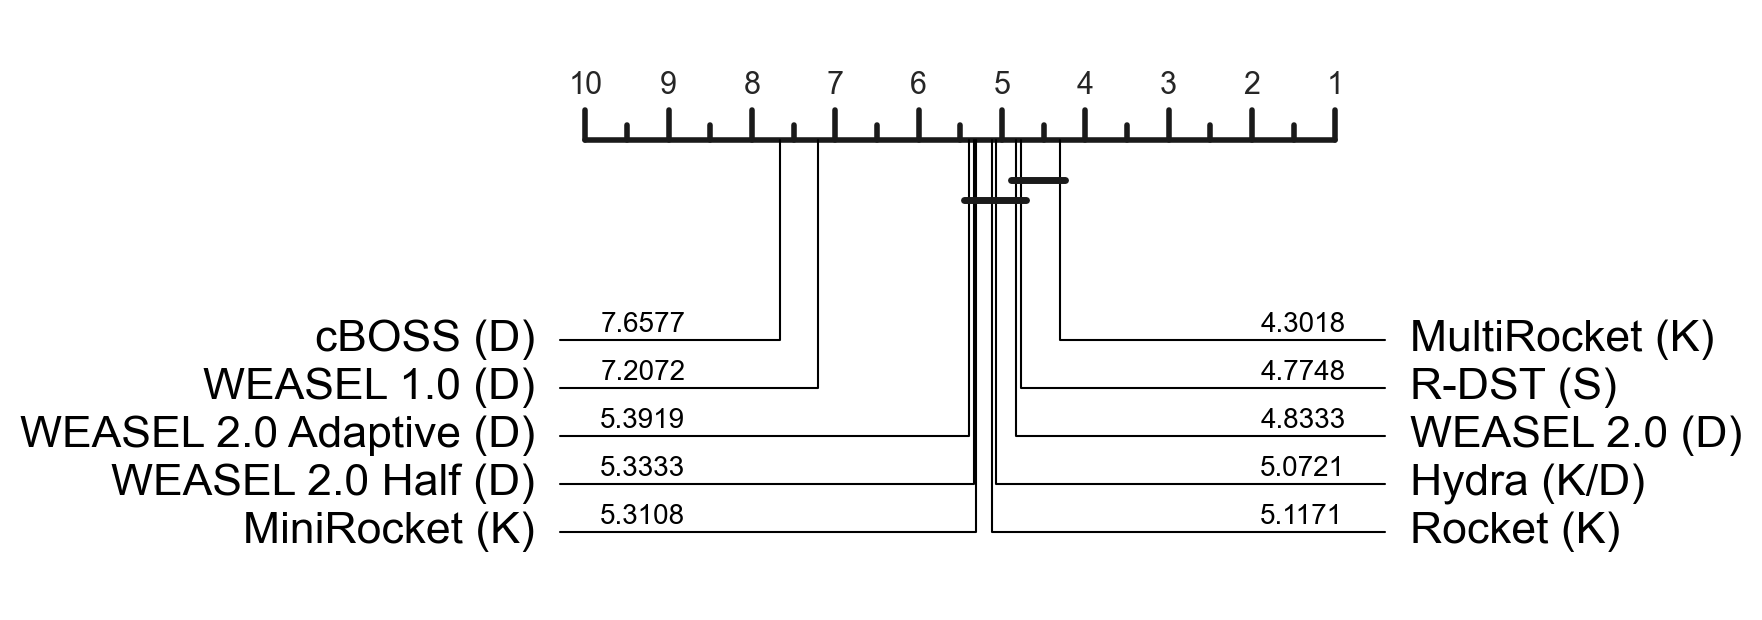

Classifer,Hydra (K/D),MiniRocket (K),MultiRocket (K),R-DST (S),Rocket (K),WEASEL 1.0 (D),WEASEL 2.0 (D),WEASEL 2.0 Adaptive (D),WEASEL 2.0 Half (D),cBOSS (D)
Mean Rank,5.68,5.87,4.93,5.32,5.73,7.68,5.55,6.21,6.14,8.12


In [10]:
from aeon.visualisation import plot_critical_difference

def critical_difference(df_subset, show=True):
    ranks = df_subset.rank(1, method = 'max', ascending=False)
    # print(ranks)
    mean_ranks = np.array(ranks.mean(axis=0))

    df_ranks = pd.DataFrame(
        list(zip(df_subset.columns.values, np.round(mean_ranks,2))), 
        columns=["Classifer", "Mean Rank"]).set_index("Classifer").T
    
    if show:
        display(df_ranks)
        for i, name in enumerate(df_subset.columns[0:]):
           print(f"{i, name}:  \t ties/wins={ranks[ranks[name] == np.min(ranks, axis=1)].shape[0], ranks[ranks[name] == 1].shape[0]}")

        print(f"Total:  \t{len(ranks)}")

    fig, ax = plot_critical_difference(df_subset.values, list(df_subset.columns))
    
    plt.show()
    
    return df_ranks



df_subset = df_pivot 
df_clean = df_subset.dropna(axis=0)

print(f"Datasets before: {len(df_subset)}, after dropping NaN rows: {len(df_clean)}")

print(df_clean.columns)
print(df_clean.head())

critical_difference(df_clean)

Classifer,Hydra (K/D),WEASEL 1.0 (D),WEASEL 2.0 (D),WEASEL 2.0 Adaptive (D),WEASEL 2.0 Half (D)
Mean Rank,2.95,4.23,2.92,3.46,3.42


(0, 'Hydra (K/D)'):  	 ties/wins=(54, 39)
(1, 'WEASEL 1.0 (D)'):  	 ties/wins=(16, 5)
(2, 'WEASEL 2.0 (D)'):  	 ties/wins=(48, 23)
(3, 'WEASEL 2.0 Adaptive (D)'):  	 ties/wins=(31, 4)
(4, 'WEASEL 2.0 Half (D)'):  	 ties/wins=(32, 4)
Total:  	111


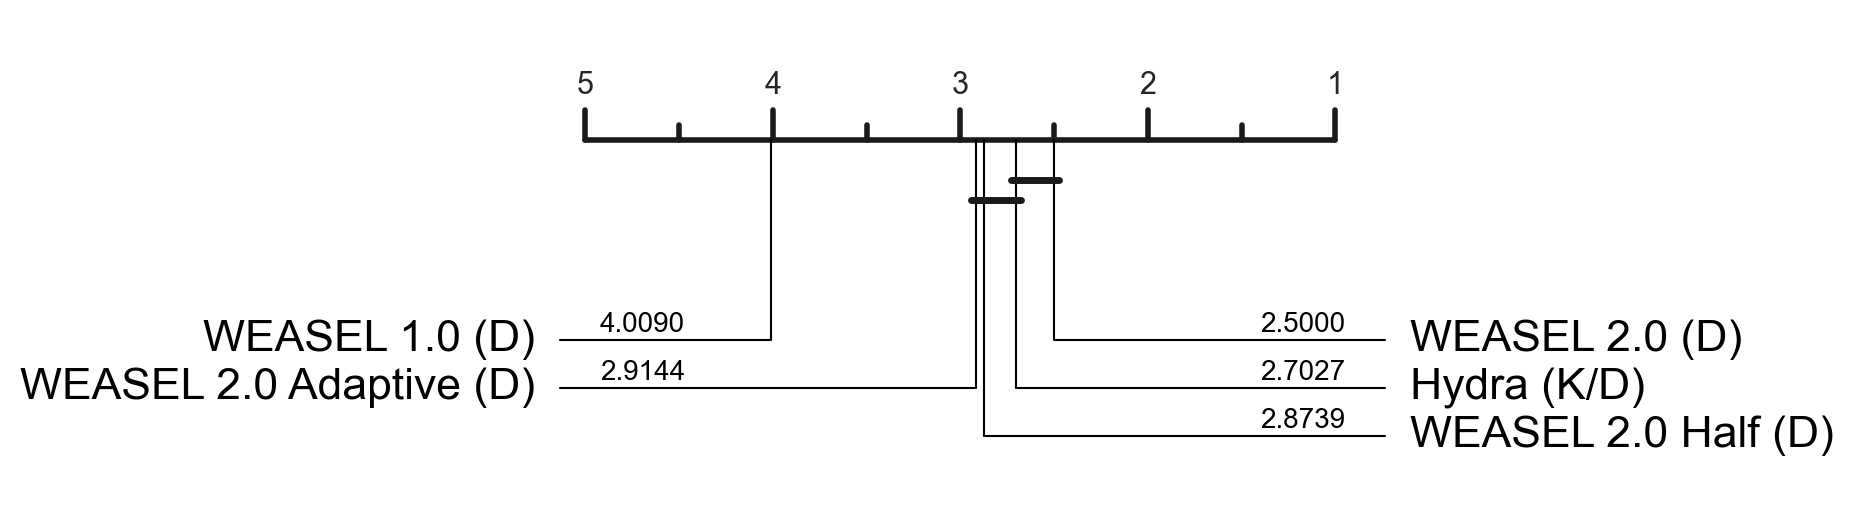

Classifer,Hydra (K/D),WEASEL 1.0 (D),WEASEL 2.0 (D),WEASEL 2.0 Adaptive (D),WEASEL 2.0 Half (D)
Mean Rank,2.95,4.23,2.92,3.46,3.42


In [11]:
subset = [0, 5,6,7,8] # plot just dictionary based methods
df_subset2 = df_clean.iloc[:, subset]
critical_difference(df_subset2, True)

In [12]:
print(df_clean.columns)
print(df_pivot.columns)

Index(['Hydra (K/D)', 'MiniRocket (K)', 'MultiRocket (K)', 'R-DST (S)',
       'Rocket (K)', 'WEASEL 1.0 (D)', 'WEASEL 2.0 (D)',
       'WEASEL 2.0 Adaptive (D)', 'WEASEL 2.0 Half (D)', 'cBOSS (D)'],
      dtype='object', name='Classifier')
Index(['Hydra (K/D)', 'MiniRocket (K)', 'MultiRocket (K)', 'R-DST (S)',
       'Rocket (K)', 'WEASEL 1.0 (D)', 'WEASEL 2.0 (D)',
       'WEASEL 2.0 Adaptive (D)', 'WEASEL 2.0 Half (D)', 'cBOSS (D)'],
      dtype='object', name='Classifier')


Index(['Hydra (K/D)', 'MiniRocket (K)', 'MultiRocket (K)', 'R-DST (S)',
       'Rocket (K)', 'WEASEL 1.0 (D)', 'WEASEL 2.0 (D)',
       'WEASEL 2.0 Adaptive (D)', 'WEASEL 2.0 Half (D)', 'cBOSS (D)'],
      dtype='object', name='Classifier')


C:\Users\gerar\AppData\Local\Temp\ipykernel_11804\1019631997.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, fontsize=12, ha='left')


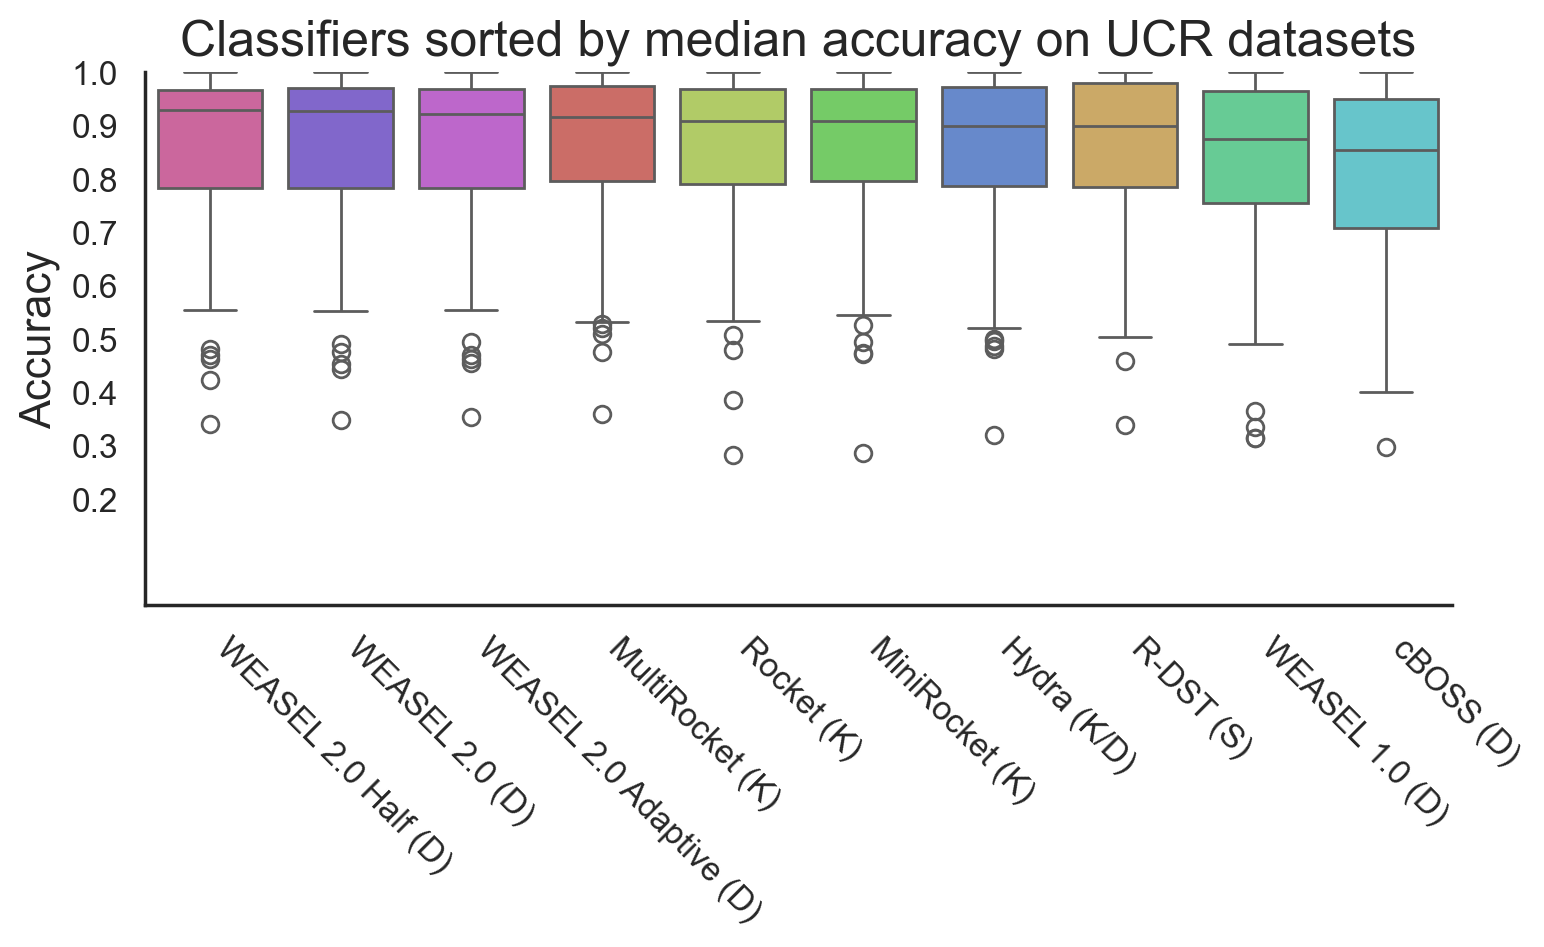

In [13]:
sns.set(font_scale=1.3)
sns.set_style("white")

print(df_clean.columns)
df_clean2 = df.dropna()


valid_datasets = df_clean.index  # datasets with no NaN across all classifiers
df_filtered = df[df["Dataset"].isin(valid_datasets)]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
g = sns.boxplot(y="Accuracy", 
                x="Classifier", 
                data=df_filtered, ax=ax, hue="Classifier", palette="hls",
                order=df_filtered.groupby("Classifier")["Accuracy"].median()
                      .sort_values(ascending=False).index)

ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, fontsize=12, ha='left')
ax.set_yticks(ax.get_yticks(), labels=ax.get_yticklabels(), fontsize=12)
ax.set_xlabel("")
ax.set_ylim(0.0, 1.0)
ax.set_title("Classifiers sorted by median accuracy on UCR datasets", fontsize=18)
sns.despine()
plt.tight_layout()

In [14]:
#def color_negative_red(val):
#    color = 'red' if val < 0 else 'black'
#    return 'color: %s' % color

#subset = [14, 8]
#subset = df_pivot.iloc[:,subset].copy()
#subset["diff"] = np.int32((subset.iloc[:,1] - subset.iloc[:,0])*100)

ds_file_name = "ucr_characteristics.csv"
datasets = pd.read_csv(f"../data/{ds_file_name}")
print(datasets.head())
#df_new = pd.merge(subset, datasets, how ='inner', on =['Dataset', 'Dataset'])
#df_new.style.applymap(color_negative_red)
# df_new.to_excel("diff.xls")
#display(df_new)

              Dataset  Train Size  Test Size  Length  No. of Classes    Type
0   AbnormalHeartbeat         303        303    3053               5   AUDIO
1               ACSF1         100        100    1460              10  DEVICE
2               Adiac         390        391     176              37   IMAGE
3  AllGestureWiimoteX         300        700       0              10  MOTION
4  AllGestureWiimoteY         300        700       0              10  MOTION


In [15]:
subset = [4, 6, 8, 9, 10, 14]
df_subset2 = df_filtered #.iloc[:,subset].copy()
df_new = pd.merge(datasets, df_subset2, how ='inner', on =['Dataset', 'Dataset'])
# df_new = df_new.melt(id_vars=["Dataset", "Type"])
display(df_new.head())
df_new.to_csv("../data/ucr_subset_dataset_type.csv")

,Dataset,Train Size,Test Size,Length,No. of Classes,Type,Classifier,Accuracy,Train-Acc
0,ACSF1,100,100,1460,10,DEVICE,MultiRocket (K),0.90,0.00000
1,ACSF1,100,100,1460,10,DEVICE,R-DST (S),0.92,0.00000
2,ACSF1,100,100,1460,10,DEVICE,Rocket (K),0.88,0.00000
3,ACSF1,100,100,1460,10,DEVICE,MiniRocket (K),0.91,0.00000
4,ACSF1,100,100,1460,10,DEVICE,WEASEL 1.0 (D),0.87,-0.25196


In [16]:
import warnings
warnings.simplefilter("ignore", UserWarning)
# warnings.simplefilter("ignore", FutureWarning)


#ds_file_name = "ucr_characteristics.csv"
#datasets = pd.read_csv(f"../data/{ds_file_name}")
#for t in datasets.Type.unique():
#    df_new = pd.merge(df_subset.reset_index(), datasets[datasets.Type==t], how ='inner', on =['Dataset', 'Dataset'])
#    df_new = df_new.iloc[:,:df_subset.shape[1]+1].set_index("Dataset")
#    if df_new.shape[0] > 2:
#        print(t, len(df_new))
#        df_ranks = critical_difference(df_new, False)
#        plt.show()        
#        display(df_ranks)

df_rt.head()

,Classifier,Dataset,Fit-Time,Predict-Time
0,MultiRocket (K),ACSF1,3.17,1.83
1,MultiRocket (K),Adiac,2.20,1.45
2,MultiRocket (K),ArrowHead,0.46,1.15
3,MultiRocket (K),BME,0.32,0.65
4,MultiRocket (K),Beef,0.72,0.35


## Reproduced Train / Predict / Total Times for 8 Classifiers 

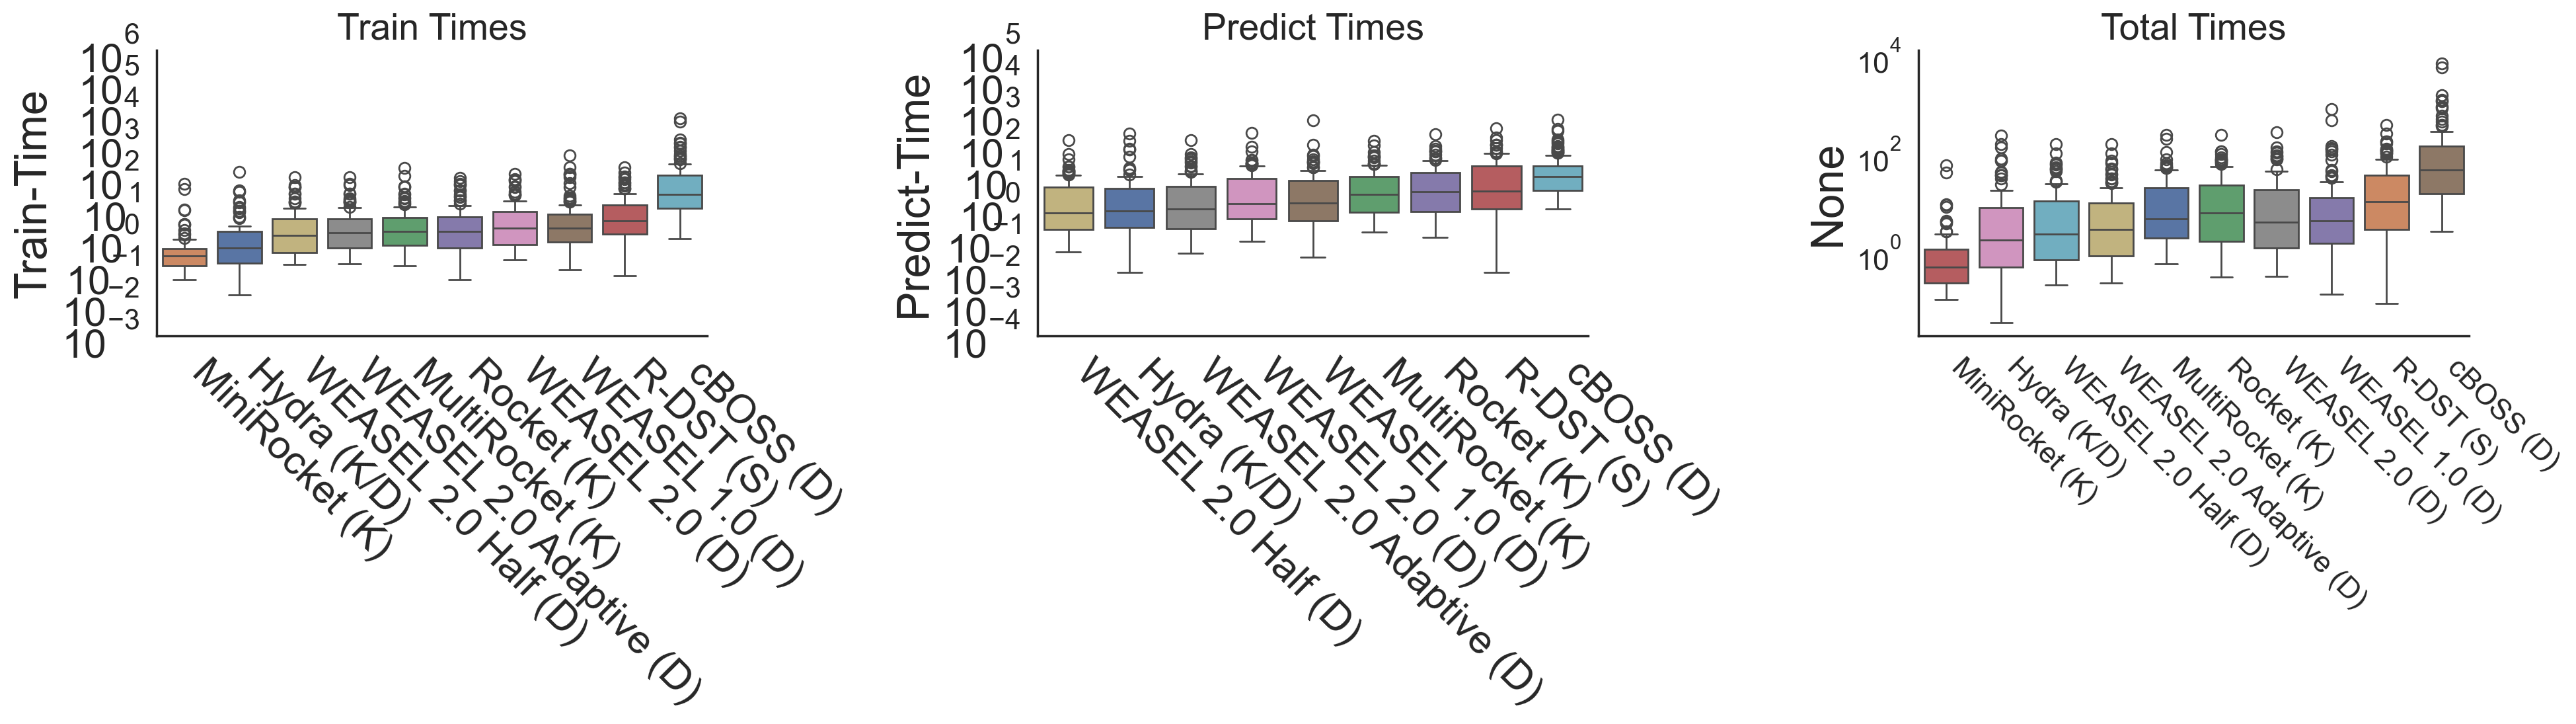

In [ ]:
sns.set(font_scale=1.5)
sns.set_style("white")

df_rt.rename(columns={"Fit-Time": "Train-Time"}, inplace=True)
df_rt.dropna(inplace=True)
#df_rt = df_rt.iloc[:, subset]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
g=sns.boxplot(y="Train-Time", x="Classifier", 
              data=df_rt.sort_values(by="Classifier"), ax=axes[0], hue="Classifier",
              order=df_rt.groupby("Classifier").median(numeric_only=True).sort_values(
                  by="Train-Time", ascending=True).reset_index()["Classifier"])
ax=axes[0]
g.set_yscale("log")
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left')
ax.set_yticks(ax.get_yticks(),)
ax.set_xlabel("")
ax.set_title("Train Times", fontsize=20)
sns.despine()

g=sns.boxplot(y="Predict-Time", x="Classifier", 
              data=df_rt.sort_values(by="Classifier"), ax=axes[1], hue="Classifier",
              order=df_rt.groupby("Classifier").median(numeric_only=True).sort_values(
                  by="Predict-Time", ascending=True).reset_index()["Classifier"][1:])
g.set_yscale("log")
ax=axes[1]
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left')
ax.set_yticks(ax.get_yticks())
ax.set_xlabel("")
ax.set_title("Predict Times", fontsize=20)
sns.despine()

g=sns.boxplot(y=df_rt["Train-Time"]+df_rt["Predict-Time"], x="Classifier", 
              data=df_rt.sort_values(by="Classifier"), ax=axes[2], hue="Classifier",
              order=df_rt.groupby("Classifier").median(numeric_only=True).sort_values(
                  by="Train-Time", ascending=True).reset_index()["Classifier"])
g.set_yscale("log")
ax=axes[2]
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left')
ax.set_yticks(ax.get_yticks())
plt.xlabel("")
plt.title("Total Times", fontsize=20)
sns.despine()
plt.tight_layout()

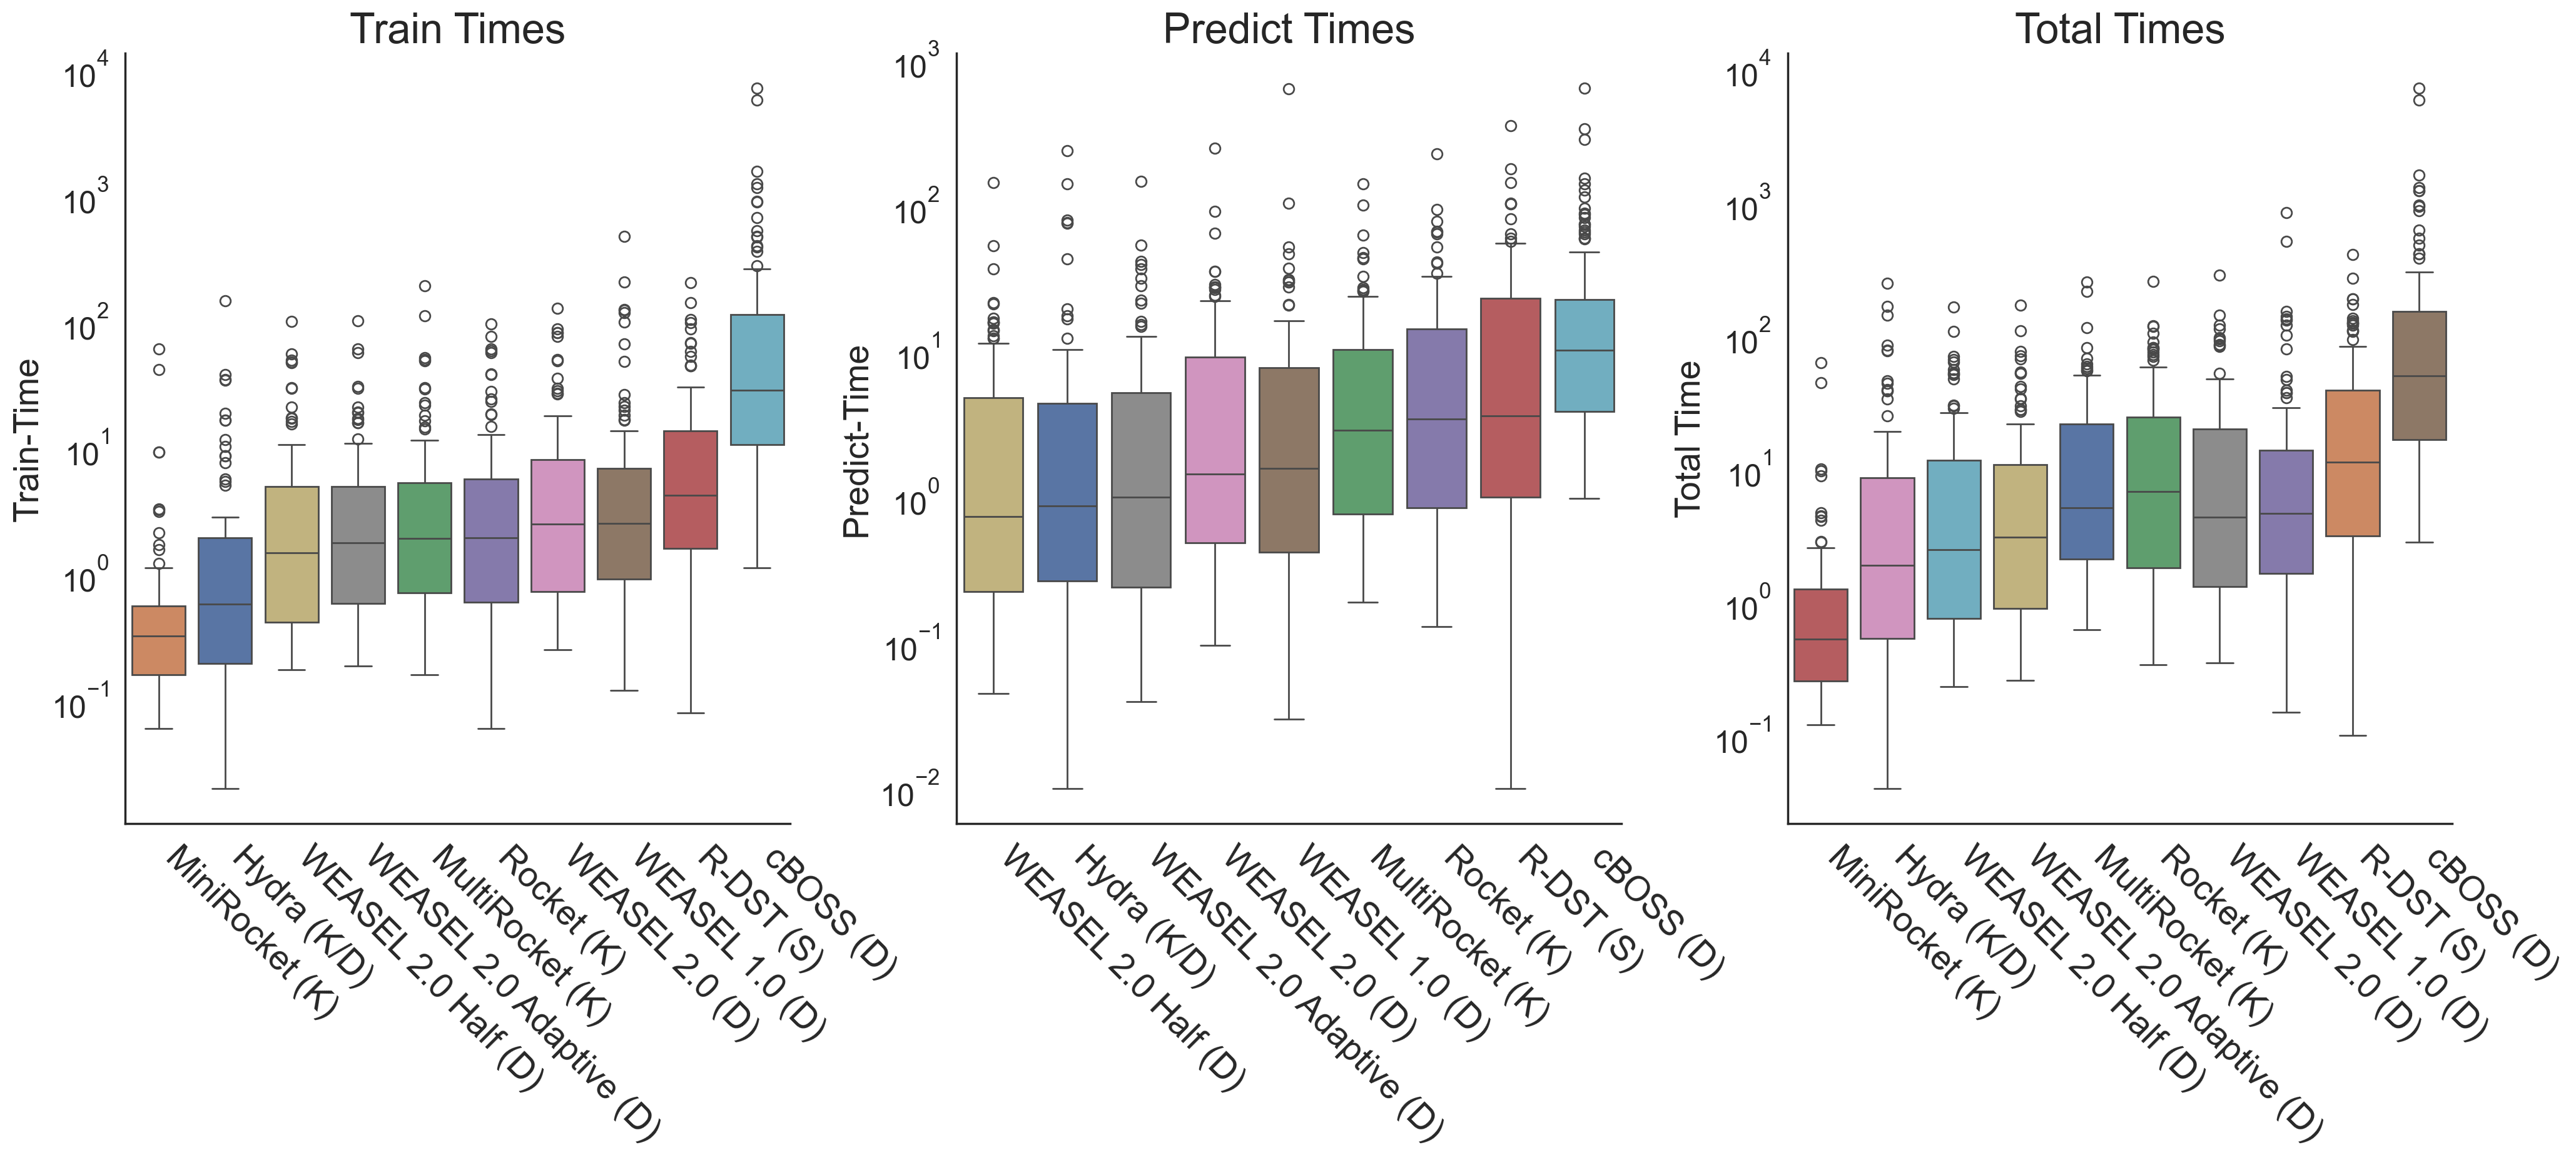

In [30]:
# Global font sizing — do this once, before plotting
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 22,
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 16,
})

sns.set(font_scale=2.0)
sns.set_style("white")

df_rt.rename(columns={"Fit-Time": "Train-Time"}, inplace=True)
df_rt.dropna(inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(24, 8), gridspec_kw={'wspace': 0.25})

# --- Train Times ---
g = sns.boxplot(y="Train-Time", x="Classifier",
                 data=df_rt.sort_values(by="Classifier"), ax=axes[0], hue="Classifier",
                 order=df_rt.groupby("Classifier").median(numeric_only=True).sort_values(
                     by="Train-Time", ascending=True).reset_index()["Classifier"])
ax = axes[0]
g.set_yscale("log")
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left', fontsize=20)
ax.tick_params(axis='y', labelsize=18)
ax.set_xlabel("")
ax.set_ylabel("Train-Time", fontsize=20)
ax.set_title("Train Times", fontsize=24)
if ax.legend_ is not None:
    ax.legend_.remove()

# --- Predict Times ---
g = sns.boxplot(y="Predict-Time", x="Classifier",
                 data=df_rt.sort_values(by="Classifier"), ax=axes[1], hue="Classifier",
                 order=df_rt.groupby("Classifier").median(numeric_only=True).sort_values(
                     by="Predict-Time", ascending=True).reset_index()["Classifier"][1:])
ax = axes[1]
g.set_yscale("log")
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left', fontsize=20)
ax.tick_params(axis='y', labelsize=18)
ax.set_xlabel("")
ax.set_ylabel("Predict-Time", fontsize=20)
ax.set_title("Predict Times", fontsize=24)
if ax.legend_ is not None:
    ax.legend_.remove()

# --- Total Times ---
g = sns.boxplot(y=df_rt["Train-Time"] + df_rt["Predict-Time"], x="Classifier",
                 data=df_rt.sort_values(by="Classifier"), ax=axes[2], hue="Classifier",
                 order=df_rt.groupby("Classifier").median(numeric_only=True).sort_values(
                     by="Train-Time", ascending=True).reset_index()["Classifier"])
ax = axes[2]
g.set_yscale("log")
ax.set_xticklabels(ax.get_xticklabels(), rotation=-45, ha='left', fontsize=20)
ax.tick_params(axis='y', labelsize=18)
ax.set_xlabel("")
ax.set_ylabel("Total Time", fontsize=20)
ax.set_title("Total Times", fontsize=24)
if ax.legend_ is not None:
    ax.legend_.remove()

sns.despine()
plt.tight_layout()
plt.savefig("runtime_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
df_pivot_rt = df_rt.pivot(index="Dataset", columns=["Classifier"], values=["Train-Time", "Predict-Time"])
pd.DataFrame({'sum': (df_pivot_rt.sum() / 60 / 60)})

sum
             Classifier                       
Train-Time   Hydra (K/D)              0.124194
             MiniRocket (K)           0.048742
             MultiRocket (K)          0.246711
             R-DST (S)                0.454506
             Rocket (K)               0.229647
             WEASEL 1.0 (D)           0.475203
             WEASEL 2.0 (D)           0.301906
             WEASEL 2.0 Adaptive (D)  0.177917
             WEASEL 2.0 Half (D)      0.188552
             cBOSS (D)                7.494478
Predict-Time Hydra (K/D)              0.260000
             MiniRocket (K)           0.015297
             MultiRocket (K)          0.321336
             R-DST (S)                0.654239
             Rocket (K)               0.412794
             WEASEL 1.0 (D)           0.385844
             WEASEL 2.0 (D)           0.300981
             WEASEL 2.0 Adaptive (D)  0.194898
             WEASEL 2.0 Half (D)      0.171923
             cBOSS (D)                1.026258

In [19]:
#pd.set_option('display.max_rows', 1000)
#display(df_pivot_rt)
df_rt # .head()

,Classifier,Dataset,Train-Time,Predict-Time
0,MultiRocket (K),ACSF1,3.1700,1.8300
1,MultiRocket (K),Adiac,2.2000,1.4500
2,MultiRocket (K),ArrowHead,0.4600,1.1500
3,MultiRocket (K),BME,0.3200,0.6500
4,MultiRocket (K),Beef,0.7200,0.3500
...,...,...,...,...
1114,WEASEL 2.0 Half (D),Wine,0.3772,0.0857
1115,WEASEL 2.0 Half (D),WordSynonyms,2.7920,2.0534
1116,WEASEL 2.0 Half (D),Worms,1.3606,0.3448
1117,WEASEL 2.0 Half (D),WormsTwoClass,1.3883,0.3486


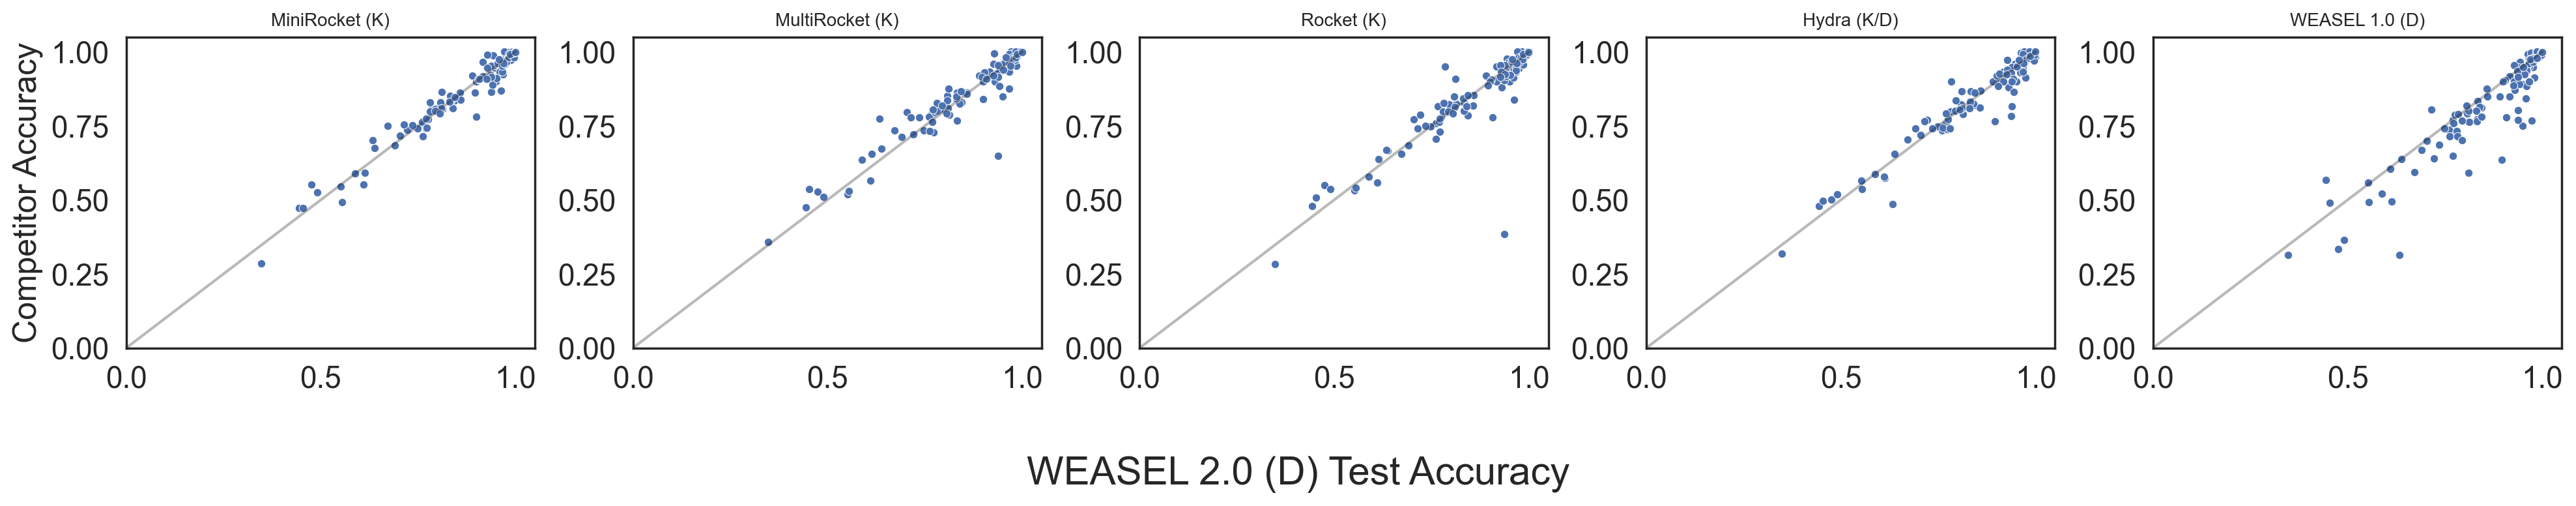

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
competitors = ["MiniRocket (K)", "MultiRocket (K)", "Rocket (K)", "Hydra (K/D)", "WEASEL 1.0 (D)"]
key = "WEASEL 2.0 (D)"

for ax, comp in zip(axes, competitors):
    sns.scatterplot(x=key, y=comp, data=df_pivot, ax=ax, s=20)
    ax.plot([0, 1], [0, 1], 'k-', alpha=0.3)
    ax.set_title(comp, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)

axes[0].set_ylabel("Competitor Accuracy")
fig.supxlabel("WEASEL 2.0 (D) Test Accuracy")
plt.tight_layout()
plt.savefig("scatter_grid_v3.png", dpi=150, bbox_inches="tight")

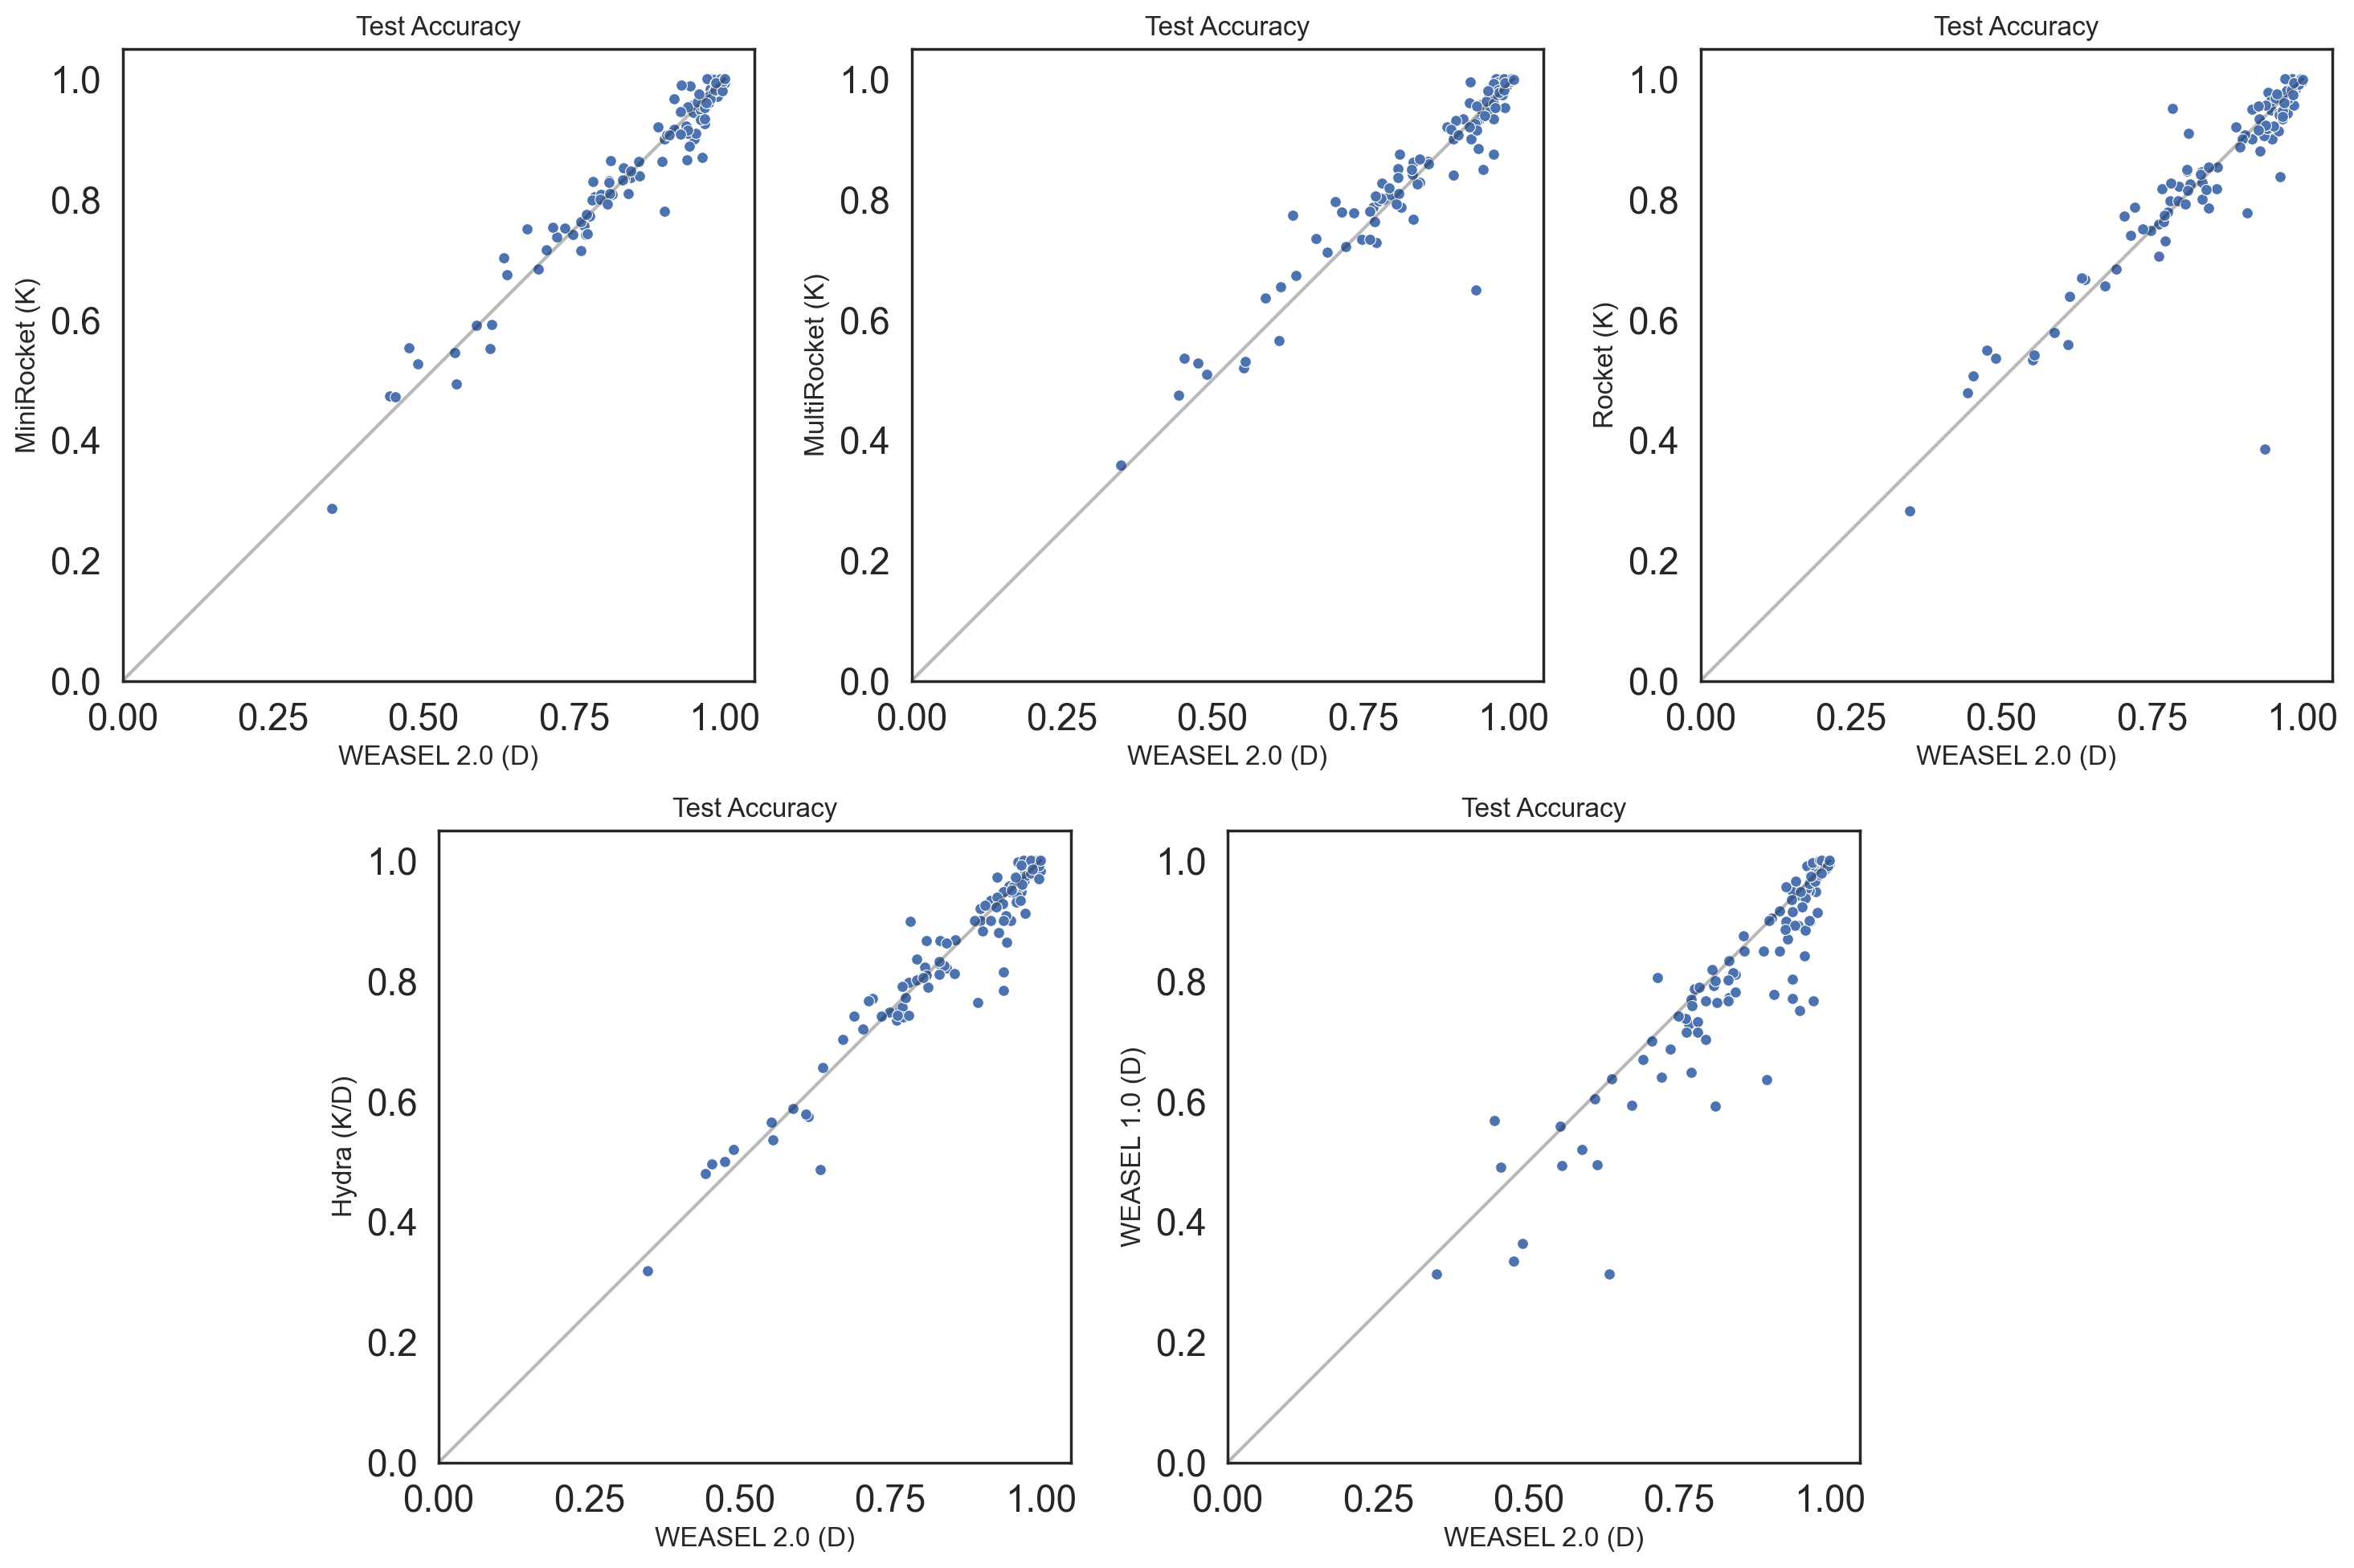

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
competitors = ["MiniRocket (K)", "MultiRocket (K)", "Rocket (K)", "Hydra (K/D)", "WEASEL 1.0 (D)"]
key = "WEASEL 2.0 (D)"

# Flatten axes for easy iteration
axes_flat = axes.flatten()

for ax, comp in zip(axes_flat, competitors):
    sns.scatterplot(x=key, y=comp, data=df_pivot, ax=ax, s=25)
    ax.plot([0, 1], [0, 1], 'k-', alpha=0.3)
    ax.set_title(f"Test Accuracy", fontsize=12)
    ax.set_xlabel("WEASEL 2.0 (D)", fontsize=12)
    ax.set_ylabel(comp, fontsize=12)
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_aspect('equal')

axes_flat[5].set_visible(False) # hide the empty 6th subplot
plt.tight_layout()

# centre bottom two plots
pos1 = axes[1, 0].get_position()
pos2 = axes[1, 1].get_position()

shift = pos1.width / 2

axes[1, 0].set_position([pos1.x0 + shift, pos1.y0, pos1.width, pos1.height])
axes[1, 1].set_position([pos2.x0 + shift, pos2.y0, pos2.width, pos2.height])
plt.savefig("scatter_grid_v3.png", dpi=150, bbox_inches="tight")
plt.show()

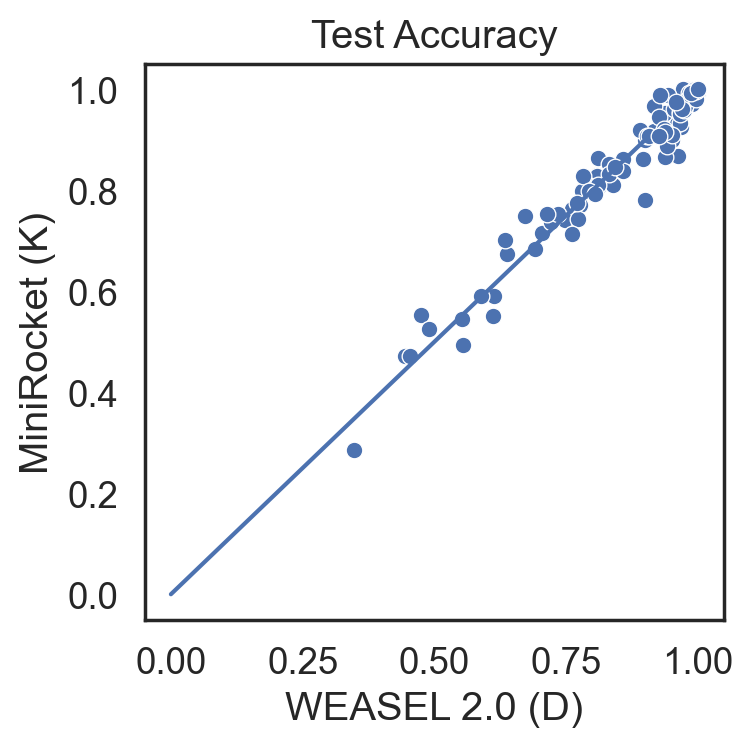

In [22]:
sns.set(font_scale=1.2)
sns.set_style("white")

key = "WEASEL 2.0 (D)"
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(x=key, y="MiniRocket (K)", data=df_subset)
ax.plot(np.arange(0, 1, 0.1), np.arange(0, 1, 0.1))
ax.set_title("Test Accuracy")
plt.tight_layout()

## Accuracy vs Runtime Tradeoff for 8 Classifiers (Figure 6)

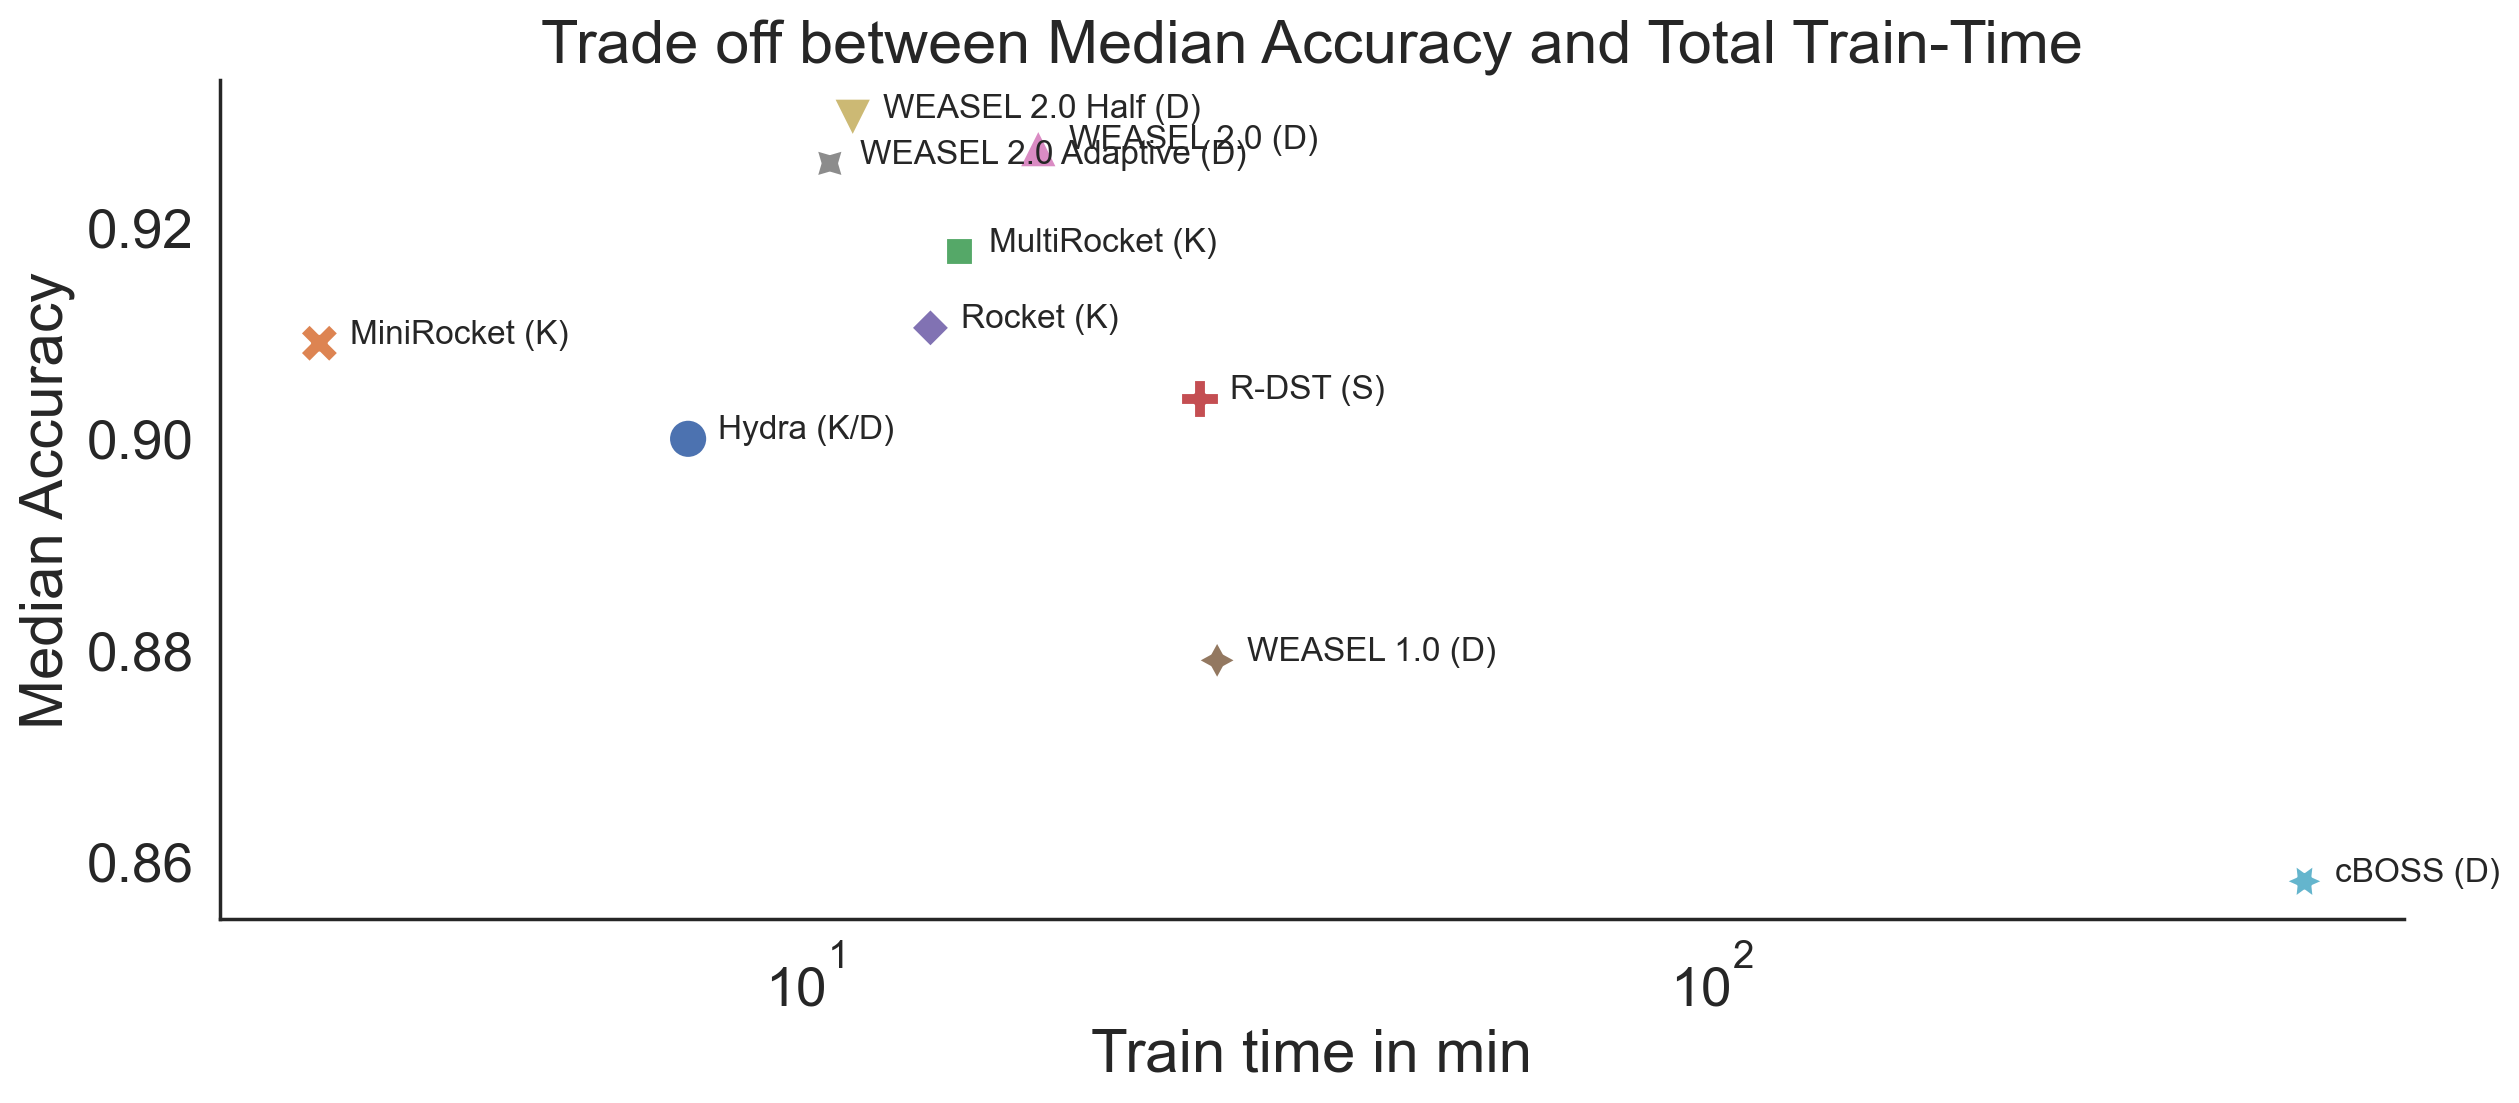

In [23]:
def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    for i, point in a.iterrows():
        ax.text(point['x'] * 1.08, point['y'], str(point['val']), fontsize=12)

sns.set(font_scale=1.8)
sns.set_style("white")

# Build summary directly from df_rt (already has all 10 classifiers)
rt_train = df_rt.groupby("Classifier")["Train-Time"].sum().reset_index()
rt_train["Train time in min"] = rt_train["Train-Time"] / 60
acc_med = df.groupby("Classifier")["Accuracy"].median().reset_index()
acc_med.columns = ["Classifier", "Acc"]
df_all = rt_train.merge(acc_med, on="Classifier")

g = sns.relplot(x="Train time in min", y="Acc",
                kind="scatter", aspect=1.5, height=6,
                data=df_all, hue="Classifier",
                style="Classifier", s=200)
g.ax.set_xscale("log")
g.ax.set_ylabel("Median Accuracy")
g.ax.set_title("Trade off between Median Accuracy and Total Train-Time", fontsize=22)
label_point(df_all["Train time in min"], df_all["Acc"], df_all["Classifier"], plt.gca())
g._legend.remove()
plt.tight_layout()
plt.savefig("accuracy_traintime_scatter_v3.pdf", bbox_inches="tight")
plt.savefig("accuracy_traintime_scatter_v3.png", dpi=150, bbox_inches="tight")

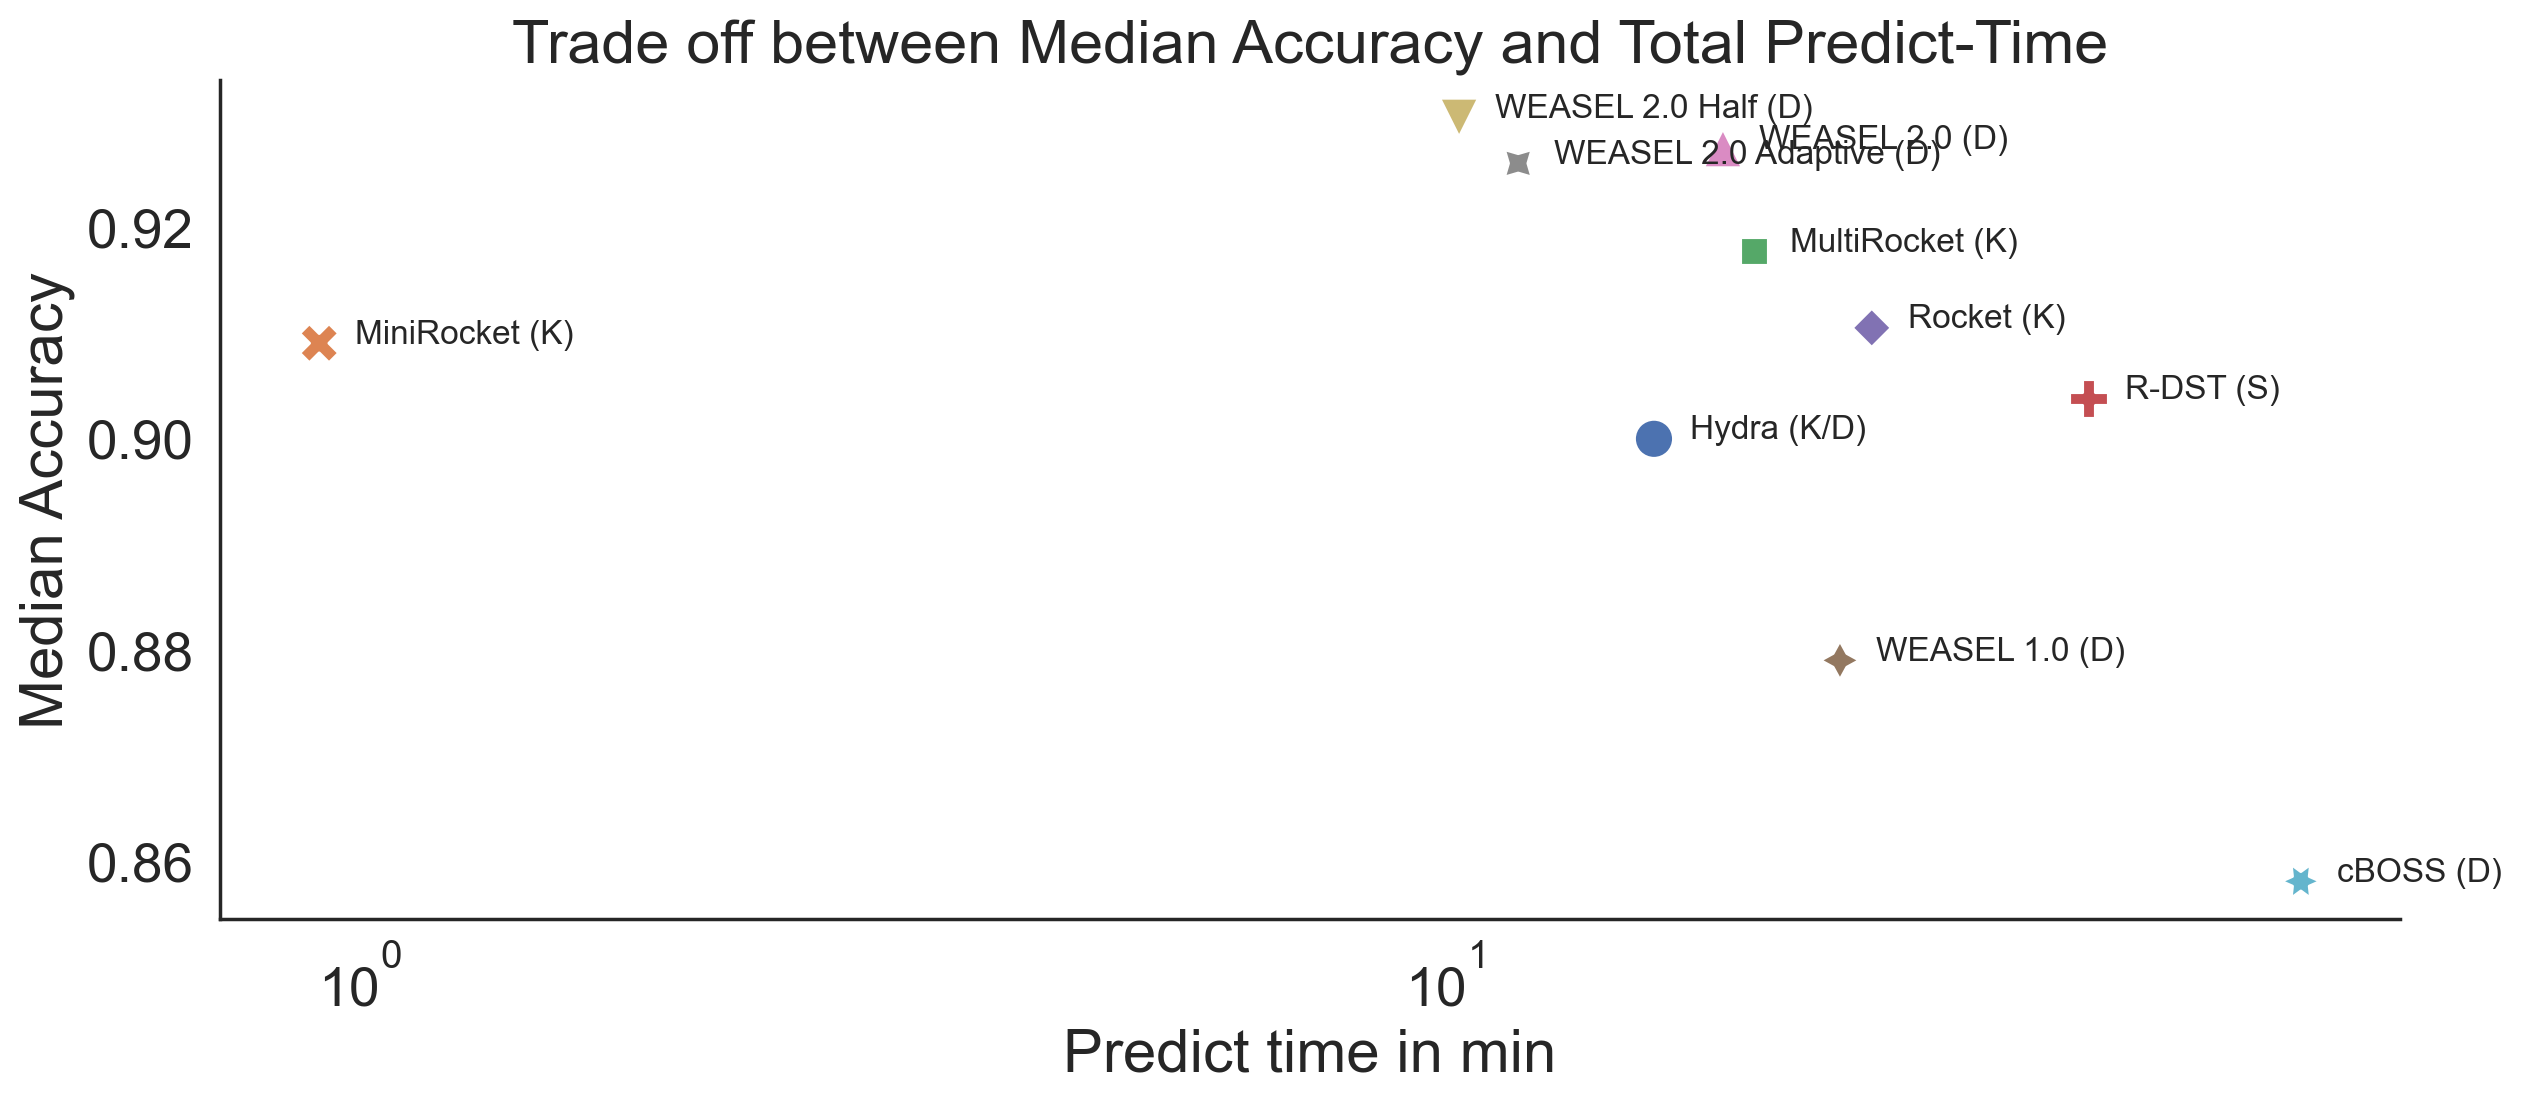

In [24]:
sns.set(font_scale=1.8)
sns.set_style("white")

rt_pred = df_rt.groupby("Classifier")["Predict-Time"].sum().reset_index()
rt_pred["Predict time in min"] = rt_pred["Predict-Time"] / 60
df_all2 = rt_pred.merge(acc_med, on="Classifier")

g = sns.relplot(x="Predict time in min", y="Acc",
                kind="scatter", aspect=1.5, height=6,
                data=df_all2, hue="Classifier",
                style="Classifier", s=200)
g.ax.set_xscale("log")
g.ax.set_ylabel("Median Accuracy")
g.ax.set_title("Trade off between Median Accuracy and Total Predict-Time", fontsize=22)
g.ax.annotate('(Fast & \n Accurate)', xy=(0.7, 0.932), xytext=(0.7, 0.932),
               fontsize=14, fontfamily='monospace', ha='left')
label_point(df_all2["Predict time in min"], df_all2["Acc"], df_all2["Classifier"], plt.gca())
g._legend.remove()
plt.tight_layout()
plt.savefig("accuracy_predicttime_scatter_v3.pdf", bbox_inches="tight")
plt.savefig("accuracy_predicttime_scatter_v3.png", dpi=150, bbox_inches="tight")

## Multi Comparison Matrix (reproduced results of 8 Classifiers)

Processing cBOSS (D), WEASEL 2.0 Half (D):   0%|          | 0/10 [00:00<?, ?it/s]              


./mcm_output/analysis.json


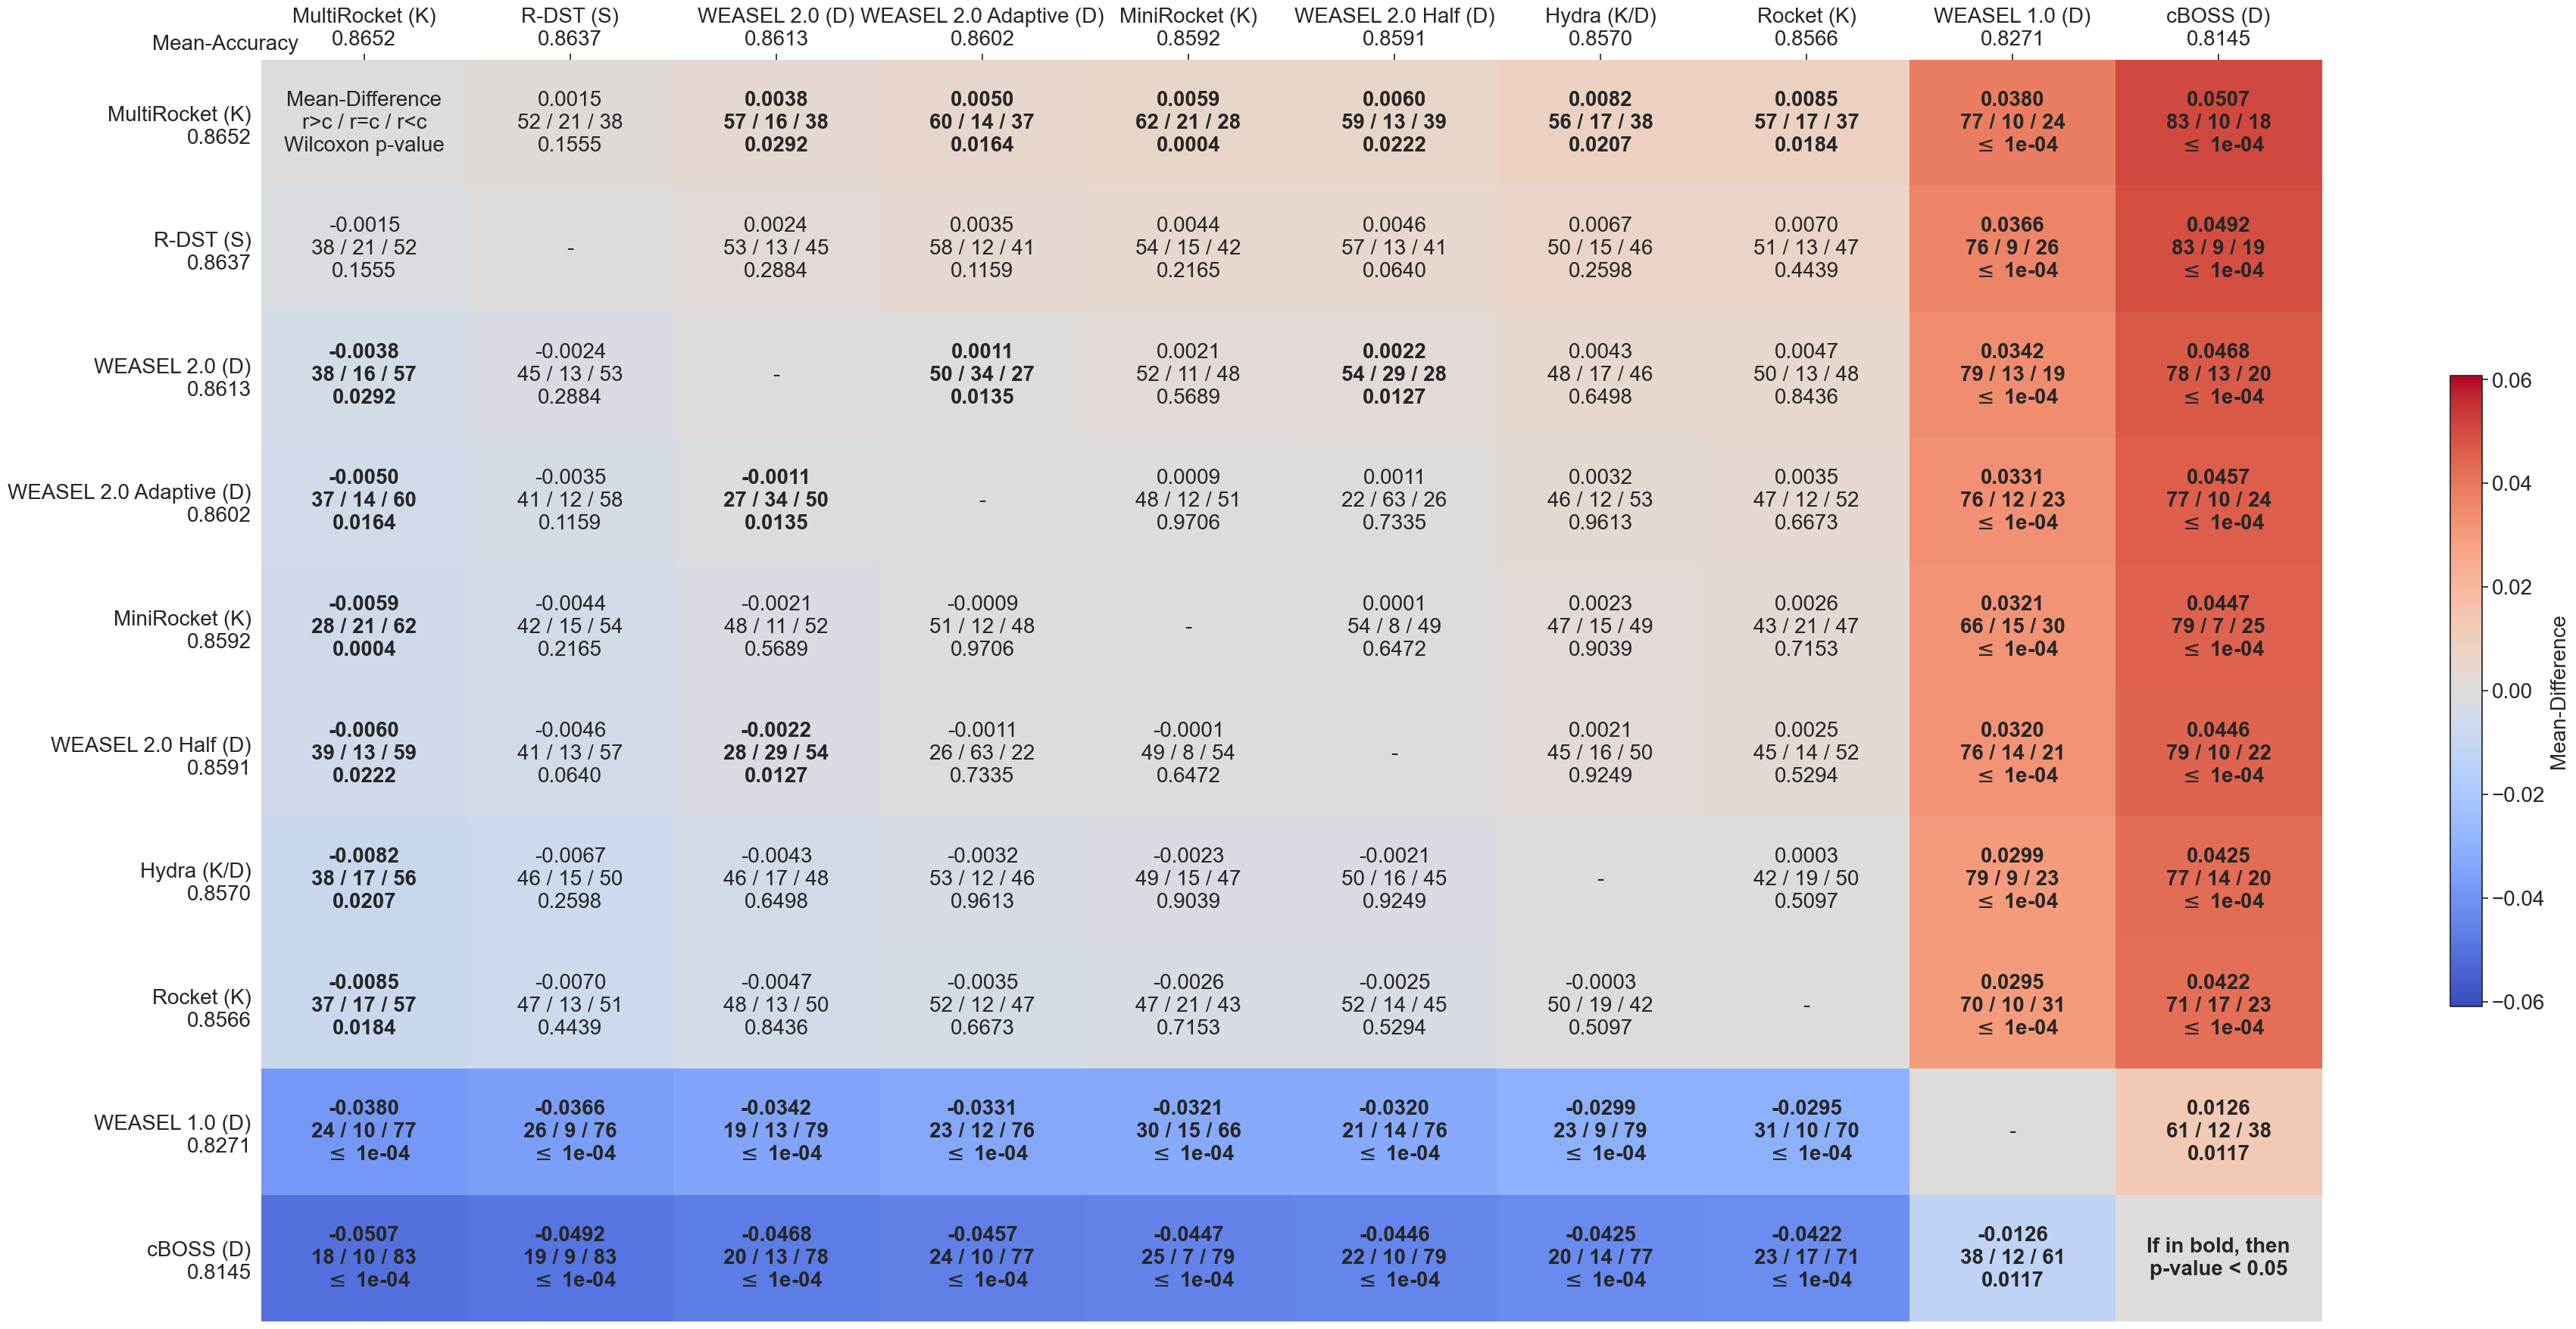

In [25]:
df_mcm = df_clean.copy()
df_mcm.index.name = "dataset_name"

os.makedirs("./mcm_output", exist_ok=True)

MCM.compare(
    output_dir="./mcm_output/",
    df_results=df_mcm,
    pdf_savename="heatmap_v2",
    png_savename="heatmap_v2",
    fig_size="38, 18",
    font_size="20",
)

display(Image(filename="./mcm_output/heatmap_v2.png"))

-EOF-